SETUP THE NWB DATA

In [158]:
import sys
sys.path.insert(0, '/code/src')

import glob
import os
import numpy as np
import pandas as pd
import seaborn as sns
import pynwb
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from datetime import datetime
from scipy.stats import linregress

sns.set_theme(context='talk', style='ticks', palette='colorblind')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.titlesize'] = 'medium'
plt.rcParams['axes.titlelocation'] = 'left'

sns.set_context('talk')
pd.set_option('display.max_columns', None)

DATA_ROOT = '/data/dynamicrouting_datacube'

SESSION_NUMBER = 2        # <-- change this to switch session

# every session available on disk, sorted so the numbering is stable
session_paths = sorted(glob.glob('%s/*/*.nwb.zarr' % DATA_ROOT))
session_ids = [os.path.basename(p).replace('.nwb.zarr', '') for p in session_paths]
print('%d sessions available' % len(session_ids))
for position, available_id in enumerate(session_ids):
    print('  %2d  %s' % (position, available_id))

session_id = session_ids[SESSION_NUMBER]
nwb_path = session_paths[SESSION_NUMBER]

# cache: re-running this cell for the same session does not reload the file
if 'session_cache' not in globals():
    session_cache = {}
if session_id not in session_cache:
    print('\nloading %s ...' % session_id)
    session_cache[session_id] = pynwb.read_nwb(nwb_path)
else:
    print('\nusing cached %s' % session_id)

session = session_cache[session_id]
trials = session.trials[:]
print('session %d: %s, %d trials' % (SESSION_NUMBER, session_id, len(trials)))

12 sessions available
   0  662892_2023-08-24
   1  664851_2023-11-16
   2  667252_2023-09-28
   3  708016_2024-04-29
   4  712815_2024-05-22
   5  713655_2024-08-09
   6  714748_2024-06-24
   7  715710_2024-07-16
   8  741137_2024-10-10
   9  742903_2024-10-23
  10  743199_2024-12-05
  11  759434_2025-02-04

using cached 667252_2023-09-28
session 2: 667252_2023-09-28, 486 trials


SETUP THE METADATA

In [159]:
from aind_data_access_api.document_db import MetadataDbClient

API_GATEWAY_HOST = 'api.allenneuraldynamics.org'
DATABASE = 'metadata_index'
COLLECTION = 'data_assets'

docdb_api_client = MetadataDbClient(host=API_GATEWAY_HOST, version='v2',
                                    database=DATABASE, collection=COLLECTION)

aggregate = [
    {'$match': {
        'data_description.project_name': 'Dynamic Routing',
        'data_description.data_level': 'derived',
        'processing.data_processes': {'$elemMatch': {
            'process_type': 'File format conversion',
            'start_date_time': {'$regex': '^2026-08-04'}}}}},
    {'$project': {
        'name': 1,
        'subject_id': '$data_description.subject_id',
        'genotype': '$subject.subject_details.genotype',
        'date_of_birth': '$subject.subject_details.date_of_birth',
        'sex': '$subject.subject_details.sex',
        'session_start_time': '$acquisition.acquisition_start_time',
        'session_end_time': '$acquisition.acquisition_end_time',
        'stimulus_epochs': '$acquisition.stimulus_epochs',
        'project_name': '$data_description.project_name',
        'modality': '$data_description.modalities.name',
        'targeted_structure': ('$acquisition.data_streams.configurations.probes'
                               '.primary_targeted_structure.name')}},
]

records = docdb_api_client.aggregate_docdb_records(pipeline=aggregate)
for r in records:
    dr = next((e for e in r.get('stimulus_epochs', [])
               if e.get('stimulus_name') == 'DynamicRouting1'), None)
    r['dr_performance'] = dr['performance_metrics'] if dr else None

metadata_df = pd.DataFrame(records)
metadata_df['trials_total'] = metadata_df['dr_performance'].apply(
    lambda x: x['trials_total'] if x else None)
metadata_df['trials_rewarded'] = metadata_df['dr_performance'].apply(
    lambda x: x['trials_rewarded'] if x else None)

# independent cross-check: these counts come from the metadata index, not the NWB file
this_session_row = metadata_df[metadata_df.name.str.contains(session_id, na=False)]
print('Metadata trials_total: %s, NWB trials: %d'
      % (this_session_row.trials_total.values, len(trials)))
print('Metadata trials_rewarded: %s, NWB is_rewarded: %d'
      % (this_session_row.trials_rewarded.values, trials.is_rewarded.sum()))
metadata_df.head(3)

Metadata trials_total: [486], NWB trials: 486
Metadata trials_rewarded: [123], NWB is_rewarded: 126


,_id,name,subject_id,genotype,date_of_birth,sex,session_start_time,session_end_time,stimulus_epochs,project_name,modality,targeted_structure,dr_performance,trials_total,trials_rewarded
0,c5bc8e0e-81ee-4e52-a7b6-90089b0dfc5f,ecephys_742903_2024-10-23_14-12-23_nwb_2026-08...,742903,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2024-05-16,Female,2024-10-23 14:12:23-07:00,2024-10-23 16:15:54.652646-07:00,"[{'object_type': 'Stimulus epoch', 'stimulus_s...",Dynamic Routing,"[Extracellular electrophysiology, Behavior, Be...","[[[Primary somatosensory area], [Caudoputamen]...","{'object_type': 'Performance metrics', 'output...",489,124
1,7f603b00-8b9f-4a66-8b9d-1d9ed27b40d4,ecephys_743199_2024-12-05_12-42-34_nwb_2026-08...,743199,VGAT-ChR2-YFP/wt,2024-05-18,Female,2024-12-05 12:42:34-08:00,2024-12-05 14:39:42.445214-08:00,"[{'object_type': 'Stimulus epoch', 'stimulus_s...",Dynamic Routing,"[Extracellular electrophysiology, Behavior, Be...","[[[Periaqueductal gray], [Red nucleus], [Red n...","{'object_type': 'Performance metrics', 'output...",490,132
2,66dc0f20-45dc-4a65-ac3a-0a04ac0e1df4,ecephys_662892_2023-08-24_14-28-28_nwb_2026-08...,662892,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2022-12-24,Female,2023-08-24 14:28:28-07:00,2023-08-24 16:28:14.588745-07:00,"[{'object_type': 'Stimulus epoch', 'stimulus_s...",Dynamic Routing,"[Extracellular electrophysiology, Behavior, Be...","[[[Piriform area], [root]]]","{'object_type': 'Performance metrics', 'output...",476,123


UNITS QUALITY CONTROL

In [160]:
units_table = session.units[:]
print('This session has %d units before quality control' % len(units_table))

# QC thresholds
MAX_ISI_VIOLATIONS_RATIO = 0.5    # lower is better
MAX_AMPLITUDE_CUTOFF = 0.1        # lower is better
MIN_PRESENCE_RATIO = 0.95         # higher is better

good_units = units_table[
    (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
    (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
    (units_table.presence_ratio > MIN_PRESENCE_RATIO)
]

this_structure_units_table = good_units[good_units.structure == 'MOs']
print('%d good units in MOs' % len(this_structure_units_table))

This session has 1181 units before quality control
190 good units in MOs


SANITY CHECKS:

Is the first lick equal to response time?

In [161]:
licks = session.processing['behavior']['licks'][:]

lick_time_array = np.sort(licks['timestamps'].values.astype(float))
print('Number of licks: %d' % (lick_time_array.size))

# distance from each scored response to the nearest recorded lick
response_time_array = trials.loc[trials.is_response, 'response_time'].values.astype(float)
insert_index_array = np.clip(np.searchsorted(lick_time_array, response_time_array), 1, lick_time_array.size - 1)
nearest_offset_array = np.minimum(
    np.abs(response_time_array - lick_time_array[insert_index_array - 1]),
    np.abs(response_time_array - lick_time_array[insert_index_array]))

print('\n|response_time - nearest lick|: median %.2f ms, max %.2f ms'
      % (np.median(nearest_offset_array) * 1e3, nearest_offset_array.max() * 1e3))

Number of licks: 4869

|response_time - nearest lick|: median nan ms, max nan ms


How is the trial structure?

In [162]:
# Trial structure
print('Trial structure: go %d + nogo %d + catch %d = %d, total trials %d'
      % (trials.is_go.sum(), trials.is_nogo.sum(), trials.is_catch.sum(),
         trials.is_go.sum() + trials.is_nogo.sum() + trials.is_catch.sum(),
         len(trials)))
print('hit %d + miss %d = go %d'
      % (trials.is_hit.sum(), trials.is_miss.sum(), trials.is_go.sum()))
print('false alarm %d + correct reject %d = nogo %d'
      % (trials.is_false_alarm.sum(), trials.is_correct_reject.sum(),
         trials.is_nogo.sum()))

# Responses types
n_catch_response = (trials.is_catch & trials.is_response).sum()
print('\nhit %d + false alarm %d + catch response %d = %d, is_response %d'
      % (trials.is_hit.sum(), trials.is_false_alarm.sum(), n_catch_response,
         trials.is_hit.sum() + trials.is_false_alarm.sum() + n_catch_response,
         trials.is_response.sum()))

# Response window
window_start_offset = trials.response_window_start_time - trials.stim_start_time
window_stop_offset = trials.response_window_stop_time - trials.stim_start_time
print('\nresponse window start offset: %.4f to %.4f s (median %.4f)'
      % (window_start_offset.min(), window_start_offset.max(),
         window_start_offset.median()))
print('response window stop  offset: %.4f to %.4f s (median %.4f)'
      % (window_stop_offset.min(), window_stop_offset.max(),
         window_stop_offset.median()))

# Save outcome trial structure
trials['outcome'] = np.select(
    [trials.is_hit, trials.is_miss, trials.is_false_alarm, trials.is_correct_reject],
    ['hit', 'miss', 'false alarm', 'correct reject'], default='unscored')

Trial structure: go 128 + nogo 296 + catch 62 = 486, total trials 486
hit 123 + miss 5 = go 128
false alarm 49 + correct reject 247 = nogo 296

hit 123 + false alarm 49 + catch response 1 = 173, is_response 173

response window start offset: 0.0552 to 0.0928 s (median 0.0561)
response window stop  offset: 0.9726 to 1.0104 s (median 0.9901)


COMPUTE THE REACTION TIME

In [163]:
# reaction time = response lick time - stimulus onset time, in seconds
trials['reaction_time'] = trials.response_time - trials.stim_start_time

# catch trials present no stimulus, so a stimulus-locked RT has no referent there.
rt_trial_mask = trials.is_response.copy()
rt_trial_mask &= ~trials.is_catch
print('Excluded %d catch response(s) from the RT analysis' % int((trials.is_response & trials.is_catch).sum()))

reaction_time_array = trials.loc[rt_trial_mask, 'reaction_time'].values
print('%d response trials analysed (of %d total responses)'
      % (reaction_time_array.size, int(trials.is_response.sum())))

print('\nnon-positive RTs: %d' % np.sum(reaction_time_array <= 0))
print('RTs outside the response window: %d'
      % np.sum((reaction_time_array < window_start_offset[rt_trial_mask].values) |
               (reaction_time_array > window_stop_offset[rt_trial_mask].values)))

Excluded 1 catch response(s) from the RT analysis
172 response trials analysed (of 173 total responses)

non-positive RTs: 0
RTs outside the response window: 0


REACTION TIMES ANALYSIS

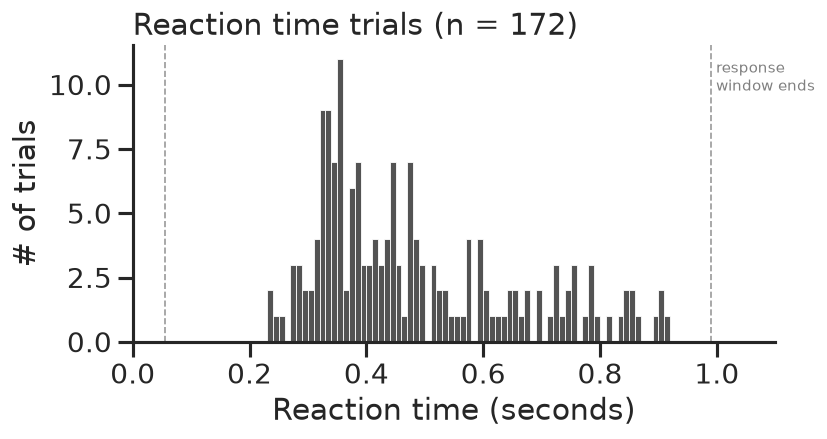

In [164]:
RT_BIN_WIDTH = 0.01          # 25 ms
RT_AXIS_LIMITS = (0, 1.1)     # display range

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(x=reaction_time_array, binwidth=RT_BIN_WIDTH, binrange=(0, RT_AXIS_LIMITS[1]),
             color='k', edgecolor='white', linewidth=0.5, ax=ax)

ax.axvline(window_start_offset.median(), color='0.6', lw=1, ls='--')
ax.axvline(window_stop_offset.median(), color='0.6', lw=1, ls='--')
ax.text(window_stop_offset.median(), ax.get_ylim()[1] * 0.95, ' response\n window ends',
        color='0.5', fontsize=9, va='top')

ax.set_xlim(*RT_AXIS_LIMITS)
ax.set_xlabel('Reaction time (seconds)')
ax.set_ylabel('# of trials')
ax.set_title('Reaction time trials (n = %d)' % (reaction_time_array.size))
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

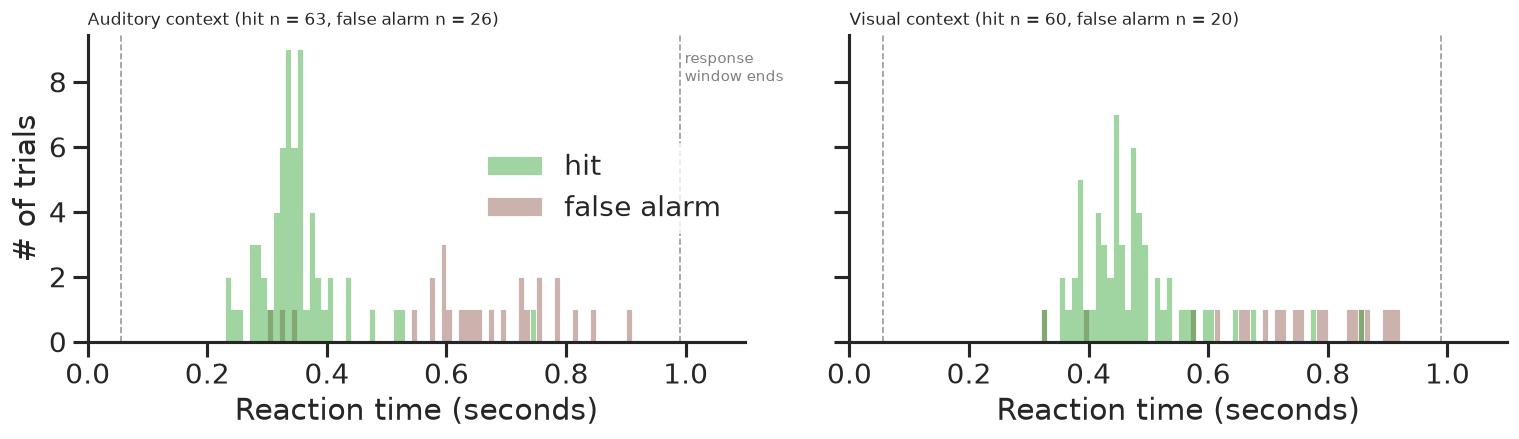

In [165]:
RT_BIN_WIDTH = 0.01           # 10 ms
RT_AXIS_LIMITS = (0, 1.1)     # display range

OUTCOME_COLORS = {'hit': 'tab:green', 'false alarm': 'tab:brown'}
RT_OUTCOMES = ['hit', 'false alarm']
CONTEXT_PANELS = [('aud', 'Auditory context'), ('vis', 'Visual context')]

rt_by_outcome_context = trials[rt_trial_mask & trials.outcome.isin(RT_OUTCOMES) & trials.reaction_time.notna()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)

for panel_index, (context_value, panel_title) in enumerate(CONTEXT_PANELS):
    ax = axes[panel_index]
    panel_data = rt_by_outcome_context[
        rt_by_outcome_context.rewarded_modality == context_value]

    sns.histplot(data=panel_data, x='reaction_time', hue='outcome',
                 hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                 binwidth=RT_BIN_WIDTH, binrange=(0, RT_AXIS_LIMITS[1]),
                 element='step', fill=True, alpha=0.45,
                 edgecolor='white', linewidth=0.5,
                 legend=(panel_index == 0), ax=ax)

    ax.axvline(window_start_offset.median(), color='0.6', lw=1, ls='--')
    ax.axvline(window_stop_offset.median(), color='0.6', lw=1, ls='--')

    ax.set_xlim(*RT_AXIS_LIMITS)
    ax.set_xlabel('Reaction time (seconds)')
    ax.set_title('%s (hit n = %d, false alarm n = %d)'
                 % (panel_title,
                    int((panel_data.outcome == 'hit').sum()),
                    int((panel_data.outcome == 'false alarm').sum())),
                 fontsize=10)
    sns.despine(ax=ax)

legend = axes[0].get_legend()
legend.set_title('')
legend.prop.set_size(8)
legend.get_frame().set_linewidth(0)

axes[0].set_ylabel('# of trials')
axes[1].set_ylabel('')
axes[0].text(window_stop_offset.median(), axes[0].get_ylim()[1] * 0.95, ' response\n window ends', color='0.5', fontsize=9, va='top')
fig.tight_layout()
plt.show()

Visual stimuli discrimination requires more time to reach the brain than the auditory stimuli.Therefore, the reaction times are slower.

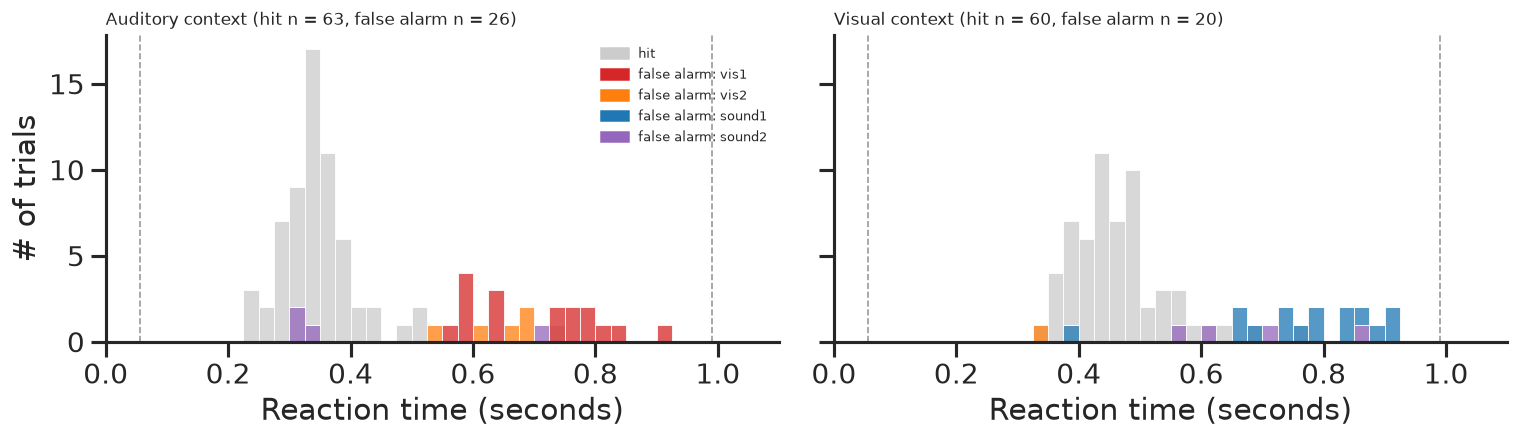

In [166]:
RT_BIN_WIDTH_FA = 0.025       # coarser 25 ms
FA_STIM_COLORS = {'vis1': 'tab:red', 'vis2': 'tab:orange',
                  'sound1': 'tab:blue', 'sound2': 'tab:purple'}
CONTEXT_PANELS = [('aud', 'Auditory context'), ('vis', 'Visual context')]

false_alarm_trials = trials[rt_trial_mask & trials.is_false_alarm & trials.reaction_time.notna()]

fa_stim_present = [s for s in FA_STIM_COLORS if s in set(false_alarm_trials.stim_name)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)

for panel_index, (context_value, panel_title) in enumerate(CONTEXT_PANELS):
    ax = axes[panel_index]
    panel_hits = trials[rt_trial_mask & trials.is_hit & (trials.rewarded_modality == context_value)]
    panel_fa = false_alarm_trials[false_alarm_trials.rewarded_modality == context_value]

    # hits as a grey backdrop, so the false alarms are the readable layer
    sns.histplot(x=panel_hits.reaction_time, binwidth=RT_BIN_WIDTH_FA,
                 binrange=(0, RT_AXIS_LIMITS[1]), color='0.8',
                 edgecolor='white', linewidth=0.5, ax=ax)
    sns.histplot(data=panel_fa, x='reaction_time', hue='stim_name',
                 hue_order=fa_stim_present, palette=FA_STIM_COLORS,
                 multiple='stack', binwidth=RT_BIN_WIDTH_FA,
                 binrange=(0, RT_AXIS_LIMITS[1]),
                 edgecolor='white', linewidth=0.5, legend=False, ax=ax)

    ax.axvline(window_start_offset.median(), color='0.6', lw=1, ls='--')
    ax.axvline(window_stop_offset.median(), color='0.6', lw=1, ls='--')
    ax.set_xlim(*RT_AXIS_LIMITS)
    ax.set_xlabel('Reaction time (seconds)')
    ax.set_title('%s (hit n = %d, false alarm n = %d)' % (panel_title, len(panel_hits), len(panel_fa)), fontsize=10)
    sns.despine(ax=ax)

legend_handles = ([Patch(color='0.8', label='hit')] + [Patch(color=FA_STIM_COLORS[s], label='false alarm: %s' % s) for s in fa_stim_present])
axes[0].legend(handles=legend_handles, fontsize=8, frameon=False, loc='upper right')

axes[0].set_ylabel('# of trials')
axes[1].set_ylabel('')
fig.tight_layout()
plt.show()

False alarms are also related with the stimuli.

REACTION TIME AND MOTIVATION ANALYSIS

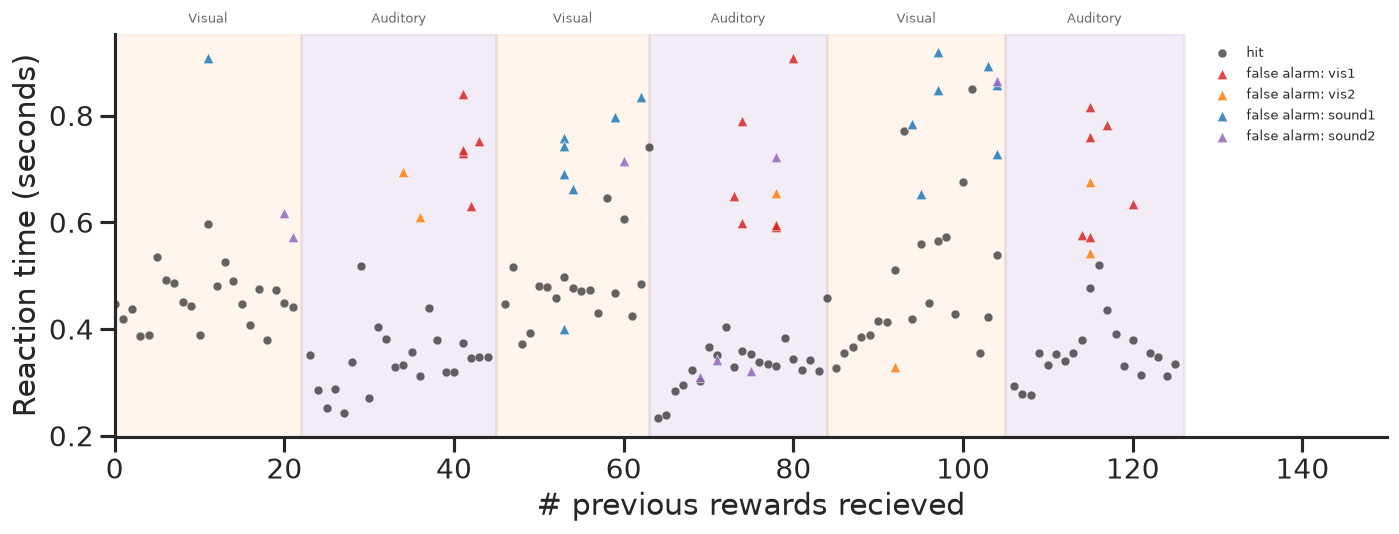

In [167]:
trials['n_previous_rewards'] = trials.is_rewarded.cumsum().shift(1).fillna(0).astype(int)

rt_scatter_data = trials[rt_trial_mask & trials.outcome.isin(RT_OUTCOMES)
                         & trials.reaction_time.notna()]

CONTEXT_SHADE = {'vis': ('tab:orange', 0.07), 'aud': ('tab:purple', 0.12)}
CONTEXT_LABELS = {'vis': 'Visual', 'aud': 'Auditory'}
HIT_COLOR = 'black'
FA_STIM_COLORS = {'vis1': 'tab:red', 'vis2': 'tab:orange', 'sound1': 'tab:blue', 'sound2': 'tab:purple'}

fig, ax = plt.subplots(figsize=(12, 4.8))
block_summary = (trials.groupby('block_index')
                 .agg(band_start=('n_previous_rewards', 'min'),
                      band_stop=('n_previous_rewards', 'max'),
                      block_context=('rewarded_modality', 'first'))
                 .sort_index())
band_edges = list(block_summary.band_start) + [block_summary.band_stop.iloc[-1]]

for position, (block_index, block_row) in enumerate(block_summary.iterrows()):
    band_start = band_edges[position]
    band_stop = band_edges[position + 1]
    shade_color, shade_alpha = CONTEXT_SHADE[block_row.block_context]
    ax.axvspan(band_start, band_stop, color=shade_color, alpha=shade_alpha, zorder=0)
    ax.annotate(CONTEXT_LABELS[block_row.block_context],
                ((band_start + band_stop) / 2, 1.02),
                xycoords=('data', 'axes fraction'),
                ha='center', va='bottom', fontsize=8, color='0.4')

hit_data = rt_scatter_data[rt_scatter_data.outcome == 'hit']
ax.scatter(hit_data.n_previous_rewards, hit_data.reaction_time,
           s=28, alpha=0.6, marker='o', color=HIT_COLOR,
           edgecolor='white', linewidth=0.4, zorder=2, label='hit')

fa_data = rt_scatter_data[rt_scatter_data.outcome == 'false alarm']
for stim_name in [s for s in FA_STIM_COLORS if s in set(fa_data.stim_name)]:
    stim_subset = fa_data[fa_data.stim_name == stim_name]
    ax.scatter(stim_subset.n_previous_rewards, stim_subset.reaction_time,
               s=40, alpha=0.85, marker='^', color=FA_STIM_COLORS[stim_name],
               edgecolor='white', linewidth=0.4, zorder=3,
               label='false alarm: %s' % stim_name)

ax.set_xlabel('# previous rewards recieved')
ax.set_ylabel('Reaction time (seconds)')
ax.legend(fontsize=8, frameon=False, ncol=1, loc='upper right')
ax.set_xlim(0, 150)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

Compute the consecutive rewarded or non-rewarded previous trials

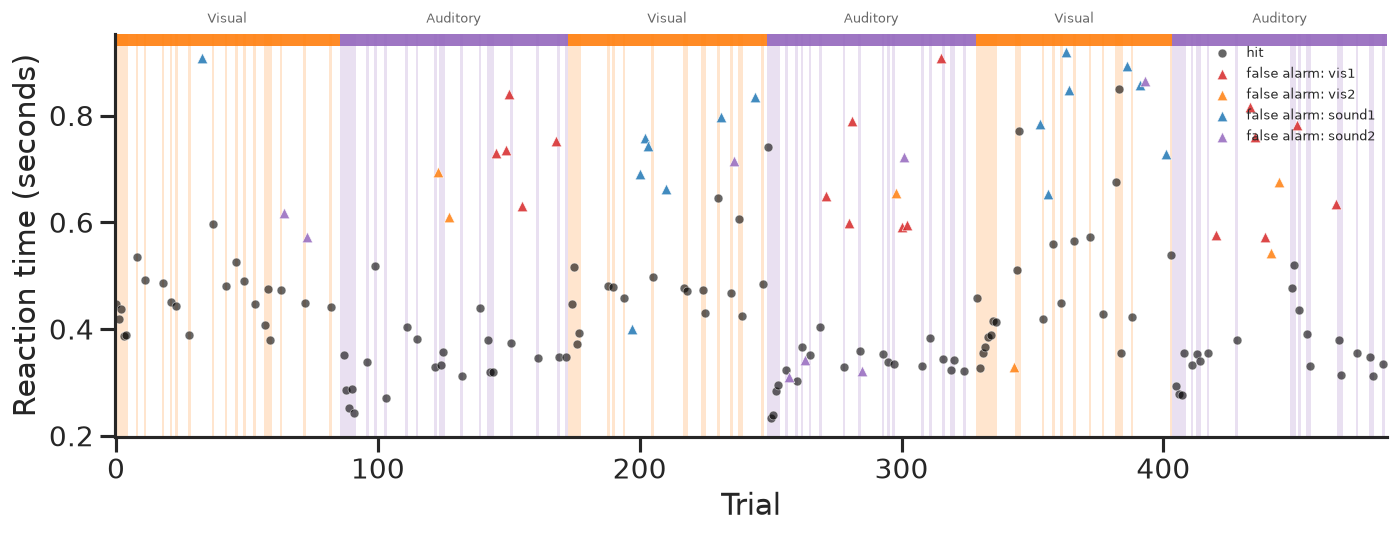

In [168]:
rt_scatter_data = trials[rt_trial_mask & trials.outcome.isin(RT_OUTCOMES) & trials.reaction_time.notna()]

CONTEXT_SHADE = {'vis': ('tab:orange', 0.20), 'aud': ('tab:purple', 0.20)}
CONTEXT_LABELS = {'vis': 'Visual', 'aud': 'Auditory'}
HIT_COLOR = 'black'
FA_STIM_COLORS = {'vis1': 'tab:red', 'vis2': 'tab:orange',
                  'sound1': 'tab:blue', 'sound2': 'tab:purple'}

fig, ax = plt.subplots(figsize=(12, 4.8))

trial_position_by_id = {trial_id: position
                        for position, trial_id in enumerate(trials.index)}
block_index_array = trials.block_index.values
context_array = trials.rewarded_modality.values
rewarded_array = trials.is_rewarded.values

for trial_position in np.flatnonzero(rewarded_array):
    shade_color, shade_alpha = CONTEXT_SHADE[context_array[trial_position]]
    ax.axvspan(trial_position - 0.5, trial_position + 0.5,
               color=shade_color, alpha=shade_alpha, lw=0, zorder=0)

for block_index in np.unique(block_index_array):
    in_block = np.flatnonzero(block_index_array == block_index)
    first_position, last_position = in_block[0], in_block[-1]
    block_context = context_array[first_position]
    shade_color, _ = CONTEXT_SHADE[block_context]
    ax.axvspan(first_position - 0.5, last_position + 0.5,
               ymin=0.97, ymax=1.0, color=shade_color, alpha=0.9, lw=0, zorder=1)
    ax.annotate(CONTEXT_LABELS[block_context],
                ((first_position + last_position) / 2, 1.02),
                xycoords=('data', 'axes fraction'),
                ha='center', va='bottom', fontsize=8, color='0.4')

hit_data = rt_scatter_data[rt_scatter_data.outcome == 'hit']
ax.scatter([trial_position_by_id[i] for i in hit_data.index], hit_data.reaction_time,
           s=28, alpha=0.6, marker='o', color=HIT_COLOR,
           edgecolor='white', linewidth=0.4, zorder=2, label='hit')

fa_data = rt_scatter_data[rt_scatter_data.outcome == 'false alarm']
for stim_name in [s for s in FA_STIM_COLORS if s in set(fa_data.stim_name)]:
    stim_subset = fa_data[fa_data.stim_name == stim_name]
    ax.scatter([trial_position_by_id[i] for i in stim_subset.index],
               stim_subset.reaction_time,
               s=40, alpha=0.85, marker='^', color=FA_STIM_COLORS[stim_name],
               edgecolor='white', linewidth=0.4, zorder=3,
               label='false alarm: %s' % stim_name)

ax.set_xlabel('Trial')
ax.set_ylabel('Reaction time (seconds)')
ax.legend(fontsize=8, frameon=False, ncol=1, loc='upper right')
ax.set_xlim(-0.5, len(trials) - 0.5)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

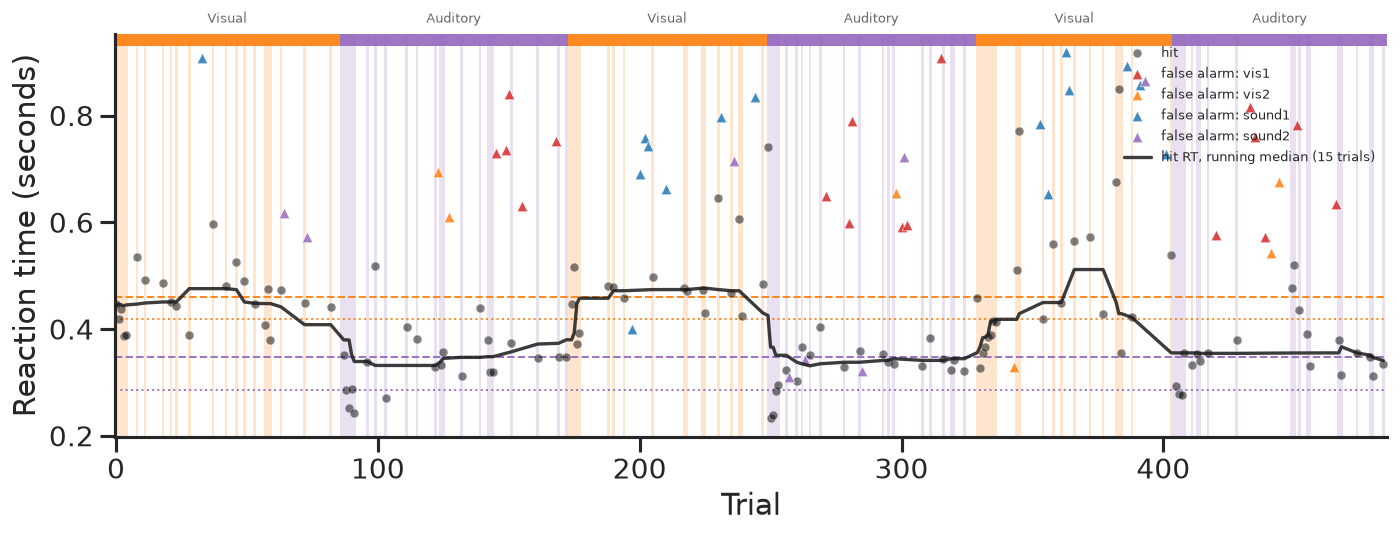

In [169]:
rt_scatter_data = trials[rt_trial_mask & trials.outcome.isin(RT_OUTCOMES)
                         & trials.reaction_time.notna()]

CONTEXT_SHADE = {'vis': ('tab:orange', 0.20), 'aud': ('tab:purple', 0.20)}
CONTEXT_LABELS = {'vis': 'Visual', 'aud': 'Auditory'}
HIT_COLOR = 'black'
FA_STIM_COLORS = {'vis1': 'tab:red', 'vis2': 'tab:orange',
                  'sound1': 'tab:blue', 'sound2': 'tab:purple'}
BASELINE_BLOCKS = [0, 1]
START_BASELINE_N = 5       # hits at the start of each block
END_BASELINE_N = 10        # hits at the end of each block
RUNNING_WINDOW = 15        # hits in the running median

fig, ax = plt.subplots(figsize=(12, 4.8))

trial_position_by_id = {trial_id: position
                        for position, trial_id in enumerate(trials.index)}
block_index_array = trials.block_index.values
context_array = trials.rewarded_modality.values
rewarded_array = trials.is_rewarded.values

for trial_position in np.flatnonzero(rewarded_array):
    shade_color, shade_alpha = CONTEXT_SHADE[context_array[trial_position]]
    ax.axvspan(trial_position - 0.5, trial_position + 0.5,
               color=shade_color, alpha=shade_alpha, lw=0, zorder=0)

for block_index in np.unique(block_index_array):
    in_block = np.flatnonzero(block_index_array == block_index)
    first_position, last_position = in_block[0], in_block[-1]
    block_context = context_array[first_position]
    shade_color, _ = CONTEXT_SHADE[block_context]
    ax.axvspan(first_position - 0.5, last_position + 0.5,
               ymin=0.97, ymax=1.0, color=shade_color, alpha=0.9, lw=0, zorder=1)
    ax.annotate(CONTEXT_LABELS[block_context],
                ((first_position + last_position) / 2, 1.02),
                xycoords=('data', 'axes fraction'),
                ha='center', va='bottom', fontsize=8, color='0.4')

hit_data = rt_scatter_data[rt_scatter_data.outcome == 'hit']
hit_position = np.array([trial_position_by_id[i] for i in hit_data.index])
ax.scatter(hit_position, hit_data.reaction_time,
           s=28, alpha=0.5, marker='o', color=HIT_COLOR,
           edgecolor='white', linewidth=0.4, zorder=2, label='hit')

fa_data = rt_scatter_data[rt_scatter_data.outcome == 'false alarm']
for stim_name in [s for s in FA_STIM_COLORS if s in set(fa_data.stim_name)]:
    stim_subset = fa_data[fa_data.stim_name == stim_name]
    ax.scatter([trial_position_by_id[i] for i in stim_subset.index],
               stim_subset.reaction_time,
               s=40, alpha=0.85, marker='^', color=FA_STIM_COLORS[stim_name],
               edgecolor='white', linewidth=0.4, zorder=3,
               label='false alarm: %s' % stim_name)

running_median = pd.Series(hit_data.reaction_time.values).rolling(
    RUNNING_WINDOW, min_periods=5, center=True).median().values
ax.plot(hit_position, running_median, color='k', lw=2, alpha=0.85, zorder=4,
        label='hit RT, running median (%d trials)' % RUNNING_WINDOW)

for block_index in BASELINE_BLOCKS:
    block_hits = hit_data[hit_data.block_index == block_index]
    if len(block_hits) < 2:
        continue
    block_rt = block_hits.reaction_time.values
    block_context = context_array[trial_position_by_id[block_hits.index[0]]]
    line_color = CONTEXT_SHADE[block_context][0]

    n_start = min(START_BASELINE_N, len(block_rt))
    n_end = min(END_BASELINE_N, len(block_rt))
    start_level = np.median(block_rt[:n_start])
    end_level = np.median(block_rt[-n_end:])

    ax.axhline(start_level, color=line_color, lw=1.2, ls=':', alpha=0.9, zorder=1)
    ax.axhline(end_level, color=line_color, lw=1.2, ls='--', alpha=0.9, zorder=1)

ax.set_xlabel('Trial')
ax.set_ylabel('Reaction time (seconds)')
ax.legend(fontsize=8, frameon=False, ncol=1, loc='upper right')
ax.set_xlim(-0.5, len(trials) - 0.5)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

Rewarded and non-rewarded streak

In [170]:
def trailing_streak(flag_array):
    """Number of consecutive True values immediately preceding each position."""
    streak = np.zeros(len(flag_array), dtype=int)
    run_length = 0
    for position, flag in enumerate(flag_array):
        streak[position] = run_length
        run_length = run_length + 1 if flag else 0
    return streak

trials['consecutive_rewarded'] = trailing_streak(trials.is_rewarded.values)
trials['consecutive_unrewarded'] = trailing_streak(~trials.is_rewarded.values)

streak_data = trials[rt_trial_mask & trials.reaction_time.notna()].copy()

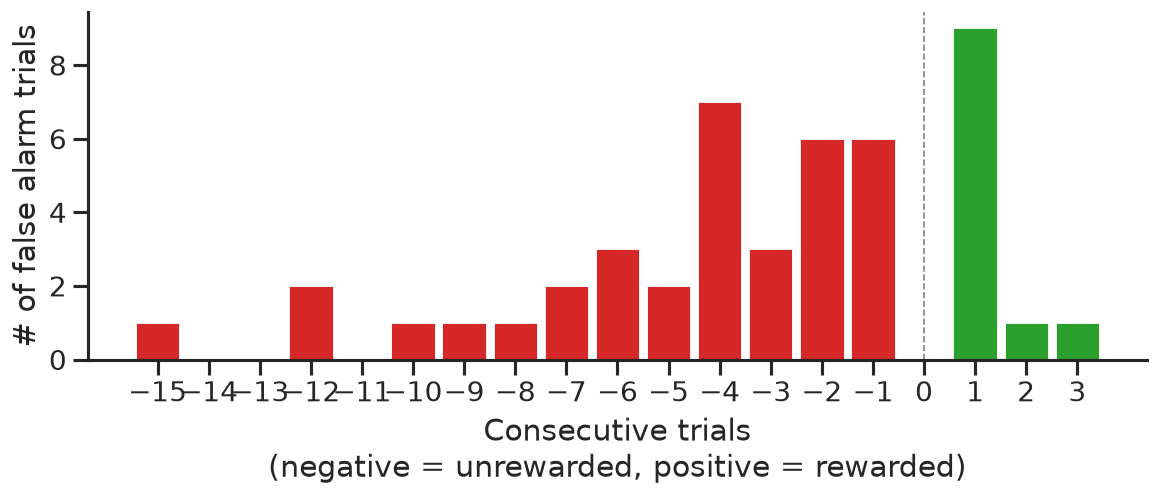

In [171]:
FA_STREAK_COLORS = {'negative': 'tab:red', 'positive': 'tab:green'}

false_alarm_streak = streak_data[streak_data.outcome == 'false alarm'].copy()

false_alarm_streak['signed_streak'] = np.where(false_alarm_streak.consecutive_rewarded > 0, false_alarm_streak.consecutive_rewarded, -false_alarm_streak.consecutive_unrewarded)

streak_min = int(false_alarm_streak.signed_streak.min())
streak_max = int(false_alarm_streak.signed_streak.max())
bin_edges = np.arange(streak_min - 0.5, streak_max + 1.5, 1)

fig, ax = plt.subplots(figsize=(10, 4.5))
counts, _ = np.histogram(false_alarm_streak.signed_streak, bins=bin_edges)
bin_centers = bin_edges[:-1] + 0.5
bar_colors = [FA_STREAK_COLORS['negative'] if c < 0 else FA_STREAK_COLORS['positive']
              for c in bin_centers]

ax.bar(bin_centers, counts, width=0.85, color=bar_colors,
       edgecolor='white', linewidth=0.5)
ax.axvline(0, color='0.5', lw=1, ls='--')

ax.set_xlabel('Consecutive trials\n'
              '(negative = unrewarded, positive = rewarded)')
ax.set_ylabel('# of false alarm trials')
ax.set_xticks(np.arange(streak_min, streak_max + 1))
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

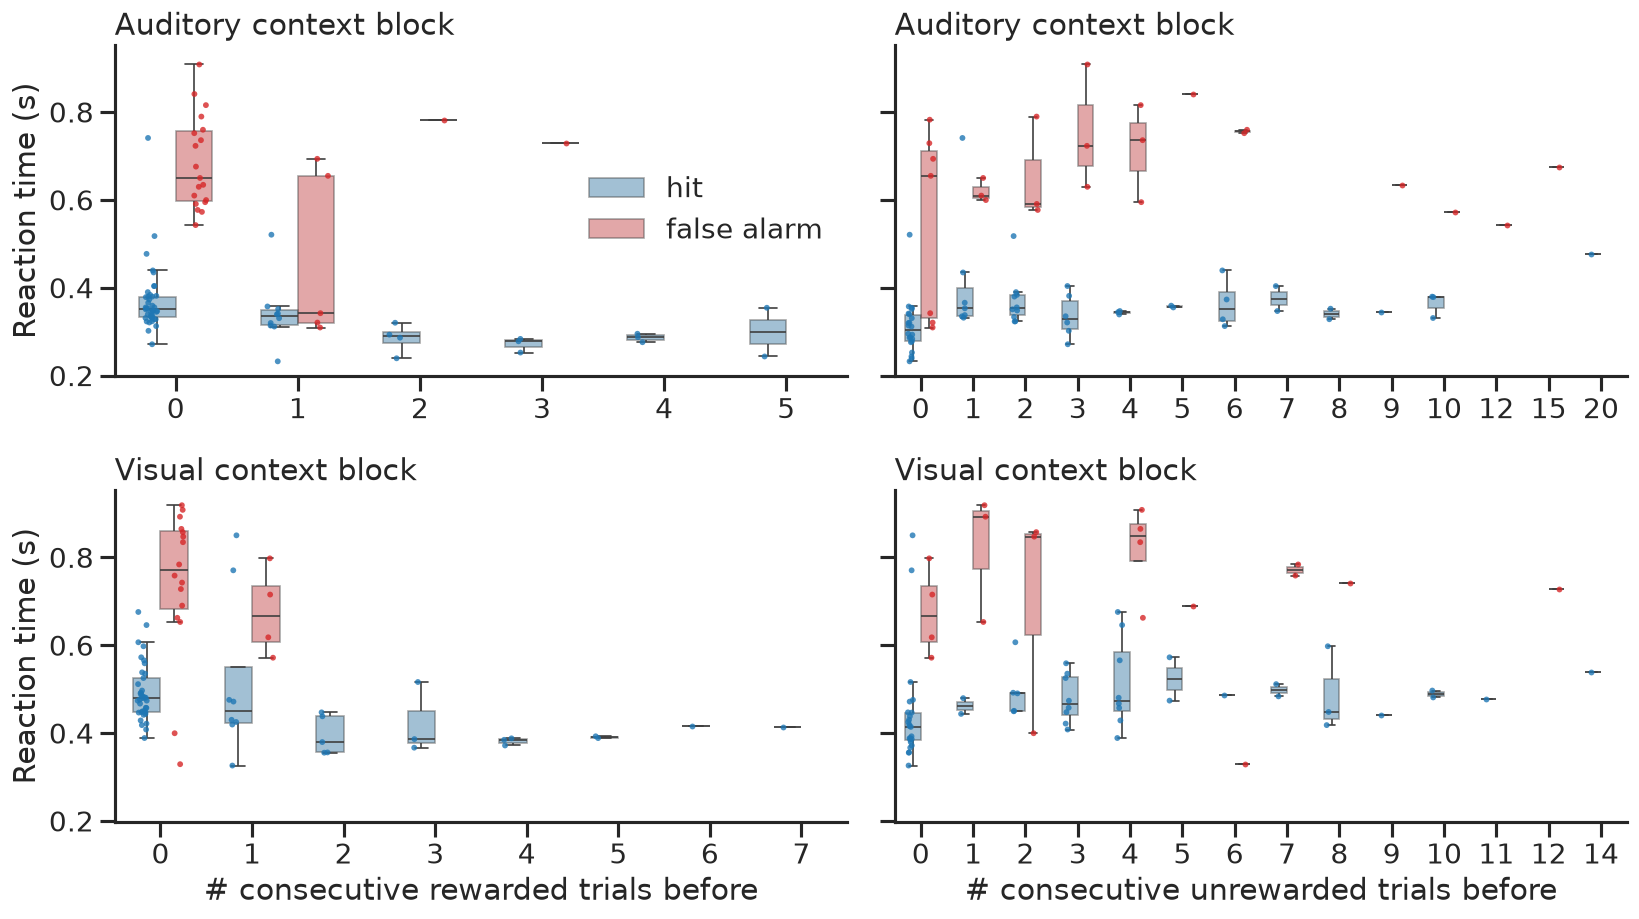

In [172]:
CONTEXT_ROWS = [('aud', 'Auditory'), ('vis', 'Visual')]
STREAK_COLUMNS = [('consecutive_rewarded', '# consecutive rewarded trials before'),
                  ('consecutive_unrewarded', '# consecutive unrewarded trials before')]
OUTCOME_COLORS = {'hit': 'tab:blue', 'false alarm': 'tab:red'}
RT_OUTCOMES = ['hit', 'false alarm']

streak_outcome_data = streak_data[streak_data.outcome.isin(RT_OUTCOMES)]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)

for row_index, (context_value, context_label) in enumerate(CONTEXT_ROWS):
    for col_index, (streak_column, column_label) in enumerate(STREAK_COLUMNS):
        ax = axes[row_index, col_index]
        panel_data = streak_outcome_data[
            streak_outcome_data.rewarded_modality == context_value]
        level_order = sorted(panel_data[streak_column].unique())

        sns.boxplot(data=panel_data, x=streak_column, y='reaction_time',
                    hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                    order=level_order, width=0.6, showfliers=False, linewidth=1,
                    boxprops={'alpha': 0.45},
                    legend=(row_index == 0 and col_index == 0), ax=ax)
        sns.stripplot(data=panel_data, x=streak_column, y='reaction_time',
                      hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                      order=level_order, dodge=True, size=3.5, alpha=0.8,
                      linewidth=0, legend=False, ax=ax)

        ax.set_title('%s context block' % (context_label), fontsize=18)
        ax.set_xlabel(column_label if row_index == 1 else '')
        ax.set_ylabel('Reaction time (s)' if col_index == 0 else '')
        sns.despine(ax=ax)

legend = axes[0, 0].get_legend()
if legend is not None:
    legend.set_title('')
    legend.prop.set_size(9)
    legend.get_frame().set_linewidth(0)

fig.tight_layout()
plt.show()

Auditory, # consecutive rewarded trials before, hit: slope -22.5 ms/trial (SE 6.5), r² = 0.163, p = 0.001, n = 63
Auditory, # consecutive rewarded trials before, false alarm: slope -28.4 ms/trial (SE 40.4), r² = 0.020, p = 0.49, n = 26
Auditory, # consecutive unrewarded trials before, hit: slope +5.1 ms/trial (SE 2.9), r² = 0.048, p = 0.085, n = 63
Auditory, # consecutive unrewarded trials before, false alarm: slope +7.0 ms/trial (SE 8.3), r² = 0.029, p = 0.41, n = 26
Visual, # consecutive rewarded trials before, hit: slope -20.3 ms/trial (SE 6.8), r² = 0.135, p = 0.0039, n = 60
Visual, # consecutive rewarded trials before, false alarm: slope -66.2 ms/trial (SE 90.0), r² = 0.029, p = 0.47, n = 20
Visual, # consecutive unrewarded trials before, hit: slope +5.8 ms/trial (SE 3.7), r² = 0.042, p = 0.12, n = 60
Visual, # consecutive unrewarded trials before, false alarm: slope -1.8 ms/trial (SE 11.5), r² = 0.001, p = 0.88, n = 20


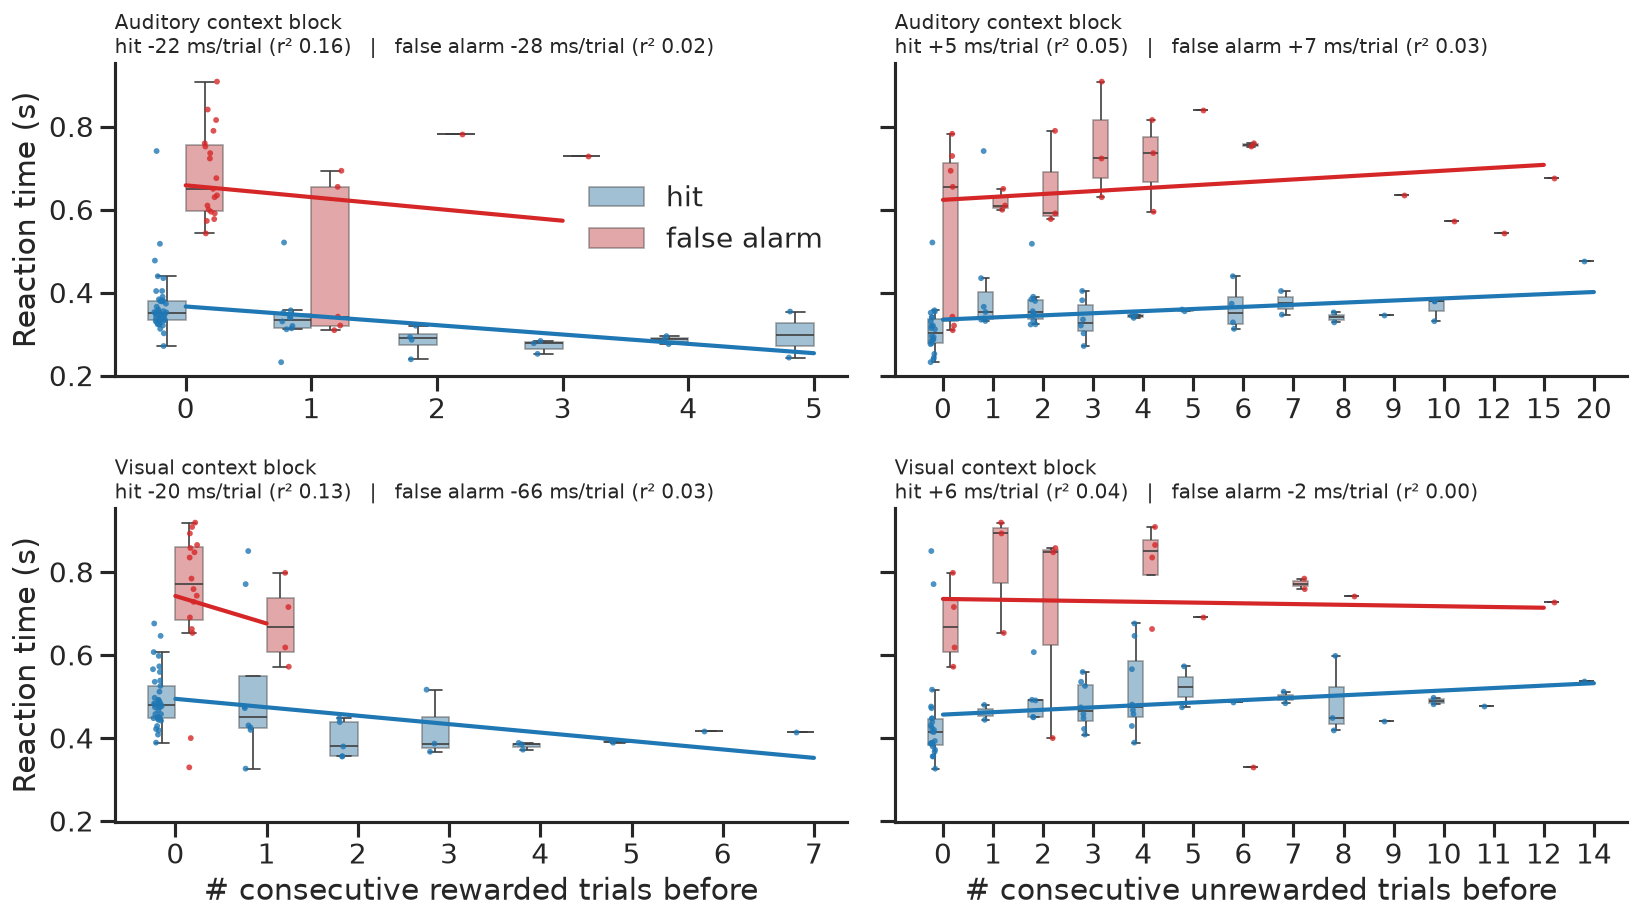

In [173]:
MIN_TRIALS_FOR_FIT = 20        # skip regressions with fewer trials than this

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)

for row_index, (context_value, context_label) in enumerate(CONTEXT_ROWS):
    for col_index, (streak_column, column_label) in enumerate(STREAK_COLUMNS):
        ax = axes[row_index, col_index]
        panel_data = streak_outcome_data[
            streak_outcome_data.rewarded_modality == context_value]
        level_order = sorted(panel_data[streak_column].unique())

        sns.boxplot(data=panel_data, x=streak_column, y='reaction_time',
                    hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                    order=level_order, width=0.6, showfliers=False, linewidth=1,
                    boxprops={'alpha': 0.45},
                    legend=(row_index == 0 and col_index == 0), ax=ax)
        sns.stripplot(data=panel_data, x=streak_column, y='reaction_time',
                      hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                      order=level_order, dodge=True, size=3.5, alpha=0.8,
                      linewidth=0, legend=False, ax=ax)

        position_by_level = {level: position
                             for position, level in enumerate(level_order)}
        title_parts = []
        for outcome_label in RT_OUTCOMES:
            outcome_data = panel_data[panel_data.outcome == outcome_label]
            x = outcome_data[streak_column].map(position_by_level).values.astype(float)
            y = outcome_data.reaction_time.values.astype(float)

            if len(x) < MIN_TRIALS_FOR_FIT or len(np.unique(x)) < 2:
                title_parts.append('%s: n=%d, not fitted' % (outcome_label, len(x)))
                print('%s, %s, %s: n = %d < %d, skipped'
                      % (context_label, column_label, outcome_label,
                         len(x), MIN_TRIALS_FOR_FIT))
                continue

            result = linregress(x, y)
            x_line = np.array([x.min(), x.max()])
            ax.plot(x_line, result.intercept + result.slope * x_line,
                    color=OUTCOME_COLORS[outcome_label], lw=2.5, zorder=5)
            title_parts.append('%s %+.0f ms/trial (r\u00b2 %.2f)'
                               % (outcome_label, result.slope * 1e3, result.rvalue ** 2))
            print('%s, %s, %s: slope %+.1f ms/trial (SE %.1f), r\u00b2 = %.3f, '
                  'p = %.2g, n = %d'
                  % (context_label, column_label, outcome_label,
                     result.slope * 1e3, result.stderr * 1e3,
                     result.rvalue ** 2, result.pvalue, len(x)))

        ax.set_title('%s context block\n%s' % (context_label, '   |   '.join(title_parts)),
                     fontsize=12)
        ax.set_xlabel(column_label if row_index == 1 else '')
        ax.set_ylabel('Reaction time (s)' if col_index == 0 else '')
        sns.despine(ax=ax)

legend = axes[0, 0].get_legend()
if legend is not None:
    legend.set_title('')
    legend.prop.set_size(9)
    legend.get_frame().set_linewidth(0)

fig.tight_layout()
plt.show()

SETUP BEHAVIOR DATA

In [174]:
behavior_module = session.processing['behavior']
print('behavior module contents: %s\n' % list(behavior_module.data_interfaces.keys()))

running_series = behavior_module['running_speed']
running_timestamps = running_series.timestamps[:]
running_speed = running_series.data[:]
side_camera_df = behavior_module['lp_side_camera'][:]
eye_df = behavior_module['eye_tracking'][:]
rewards_df = behavior_module['rewards'][:]

behavior module contents: ['facemap_front_camera', 'facemap_side_camera', 'running_speed', 'dlc_eye_camera', 'eye_tracking', 'licks', 'lp_front_camera', 'lp_side_camera', 'quiescent_interval_violations', 'rewards']



In [175]:
TRIAL_WINDOW = 'quiescent'      # 'quiescent' = 1.5 s pre-stimulus; 'whole_trial' = start to stop
QUIESCENT_WINDOW_S = 1.5
SIDE_CAMERA_FRAME_HEIGHT = 492


def get_facial_feature(part_name, facial_features_df,
                       frame_height=SIDE_CAMERA_FRAME_HEIGHT):
    """Vertical keypoint position, masked and interpolated (workshop 1)."""
    confidence = facial_features_df['%s_likelihood' % part_name]
    temporal_norm = facial_features_df['%s_temporal_norm' % part_name]

    y = frame_height - facial_features_df['%s_y' % part_name].astype(float)
    y[(confidence < 0.99)
      | (temporal_norm > np.nanmean(temporal_norm) + 2 * np.nanstd(temporal_norm))] = np.nan

    y_centered = y - np.nanmean(y)
    y_abs_centered = np.abs(y_centered)
    y_centered[y_abs_centered > np.nanmean(y_abs_centered)
               + 2 * np.nanstd(y_abs_centered)] = np.nan
    return pd.Series(y_centered).ffill().bfill().to_numpy()


def get_trialwise_mean_and_sd(x, timestamps, start, stop):
    """Mean and standard deviation of a signal within each trial window.

    Mean gives the level, SD gives within-trial variability. Returns two arrays.
    """
    x = np.asarray(x, dtype=float)
    timestamps = np.asarray(timestamps, dtype=float)
    mean_array = np.full(len(start), np.nan)
    sd_array = np.full(len(start), np.nan)
    for trial_position, (window_start, window_stop) in enumerate(zip(start, stop)):
        in_window = (timestamps >= window_start) & (timestamps <= window_stop)
        if in_window.sum() >= 2:
            mean_array[trial_position] = np.nanmean(x[in_window])
            sd_array[trial_position] = np.nanstd(x[in_window])
    return mean_array, sd_array


# Window of analysis
if TRIAL_WINDOW == 'quiescent':
    trial_window_start = trials.stim_start_time.values - QUIESCENT_WINDOW_S
    trial_window_stop = trials.stim_start_time.values
else:
    trial_window_start = trials.start_time.values
    trial_window_stop = trials.stop_time.values

window_duration = trial_window_stop - trial_window_start

# --- continuous signals -----------------------------------------------------
running_speed_clean = pd.Series(running_speed).interpolate(limit_direction='both').to_numpy()

pupil_area = eye_df['pupil_area'].astype(float).to_numpy().copy()
pupil_area[eye_df['pupil_is_bad_frame'].to_numpy().astype(bool)] = np.nan
pupil_area = pd.Series(pupil_area).interpolate(limit_direction='both').to_numpy()

side_camera_timestamps = side_camera_df['timestamps'].values.astype(float)
eye_timestamps = eye_df['timestamps'].values.astype(float)

signal_sources = [('running_speed', running_speed_clean, running_timestamps),
                  ('pupil_area', pupil_area, eye_timestamps)]
for column_name, keypoint_name in [('ear', 'ear_base_l'), ('nose', 'nose_tip'), ('jaw', 'jaw'), ('whiskers', 'whisker_pad_l_side')]:
    signal_sources.append((column_name, get_facial_feature(keypoint_name, side_camera_df), side_camera_timestamps))

# Compute mean and SD per trial
for column_name, signal_array, timestamp_array in signal_sources:
    mean_array, sd_array = get_trialwise_mean_and_sd(signal_array, timestamp_array, trial_window_start, trial_window_stop)
    trials[column_name + '_mean'] = mean_array
    trials[column_name + '_sd'] = sd_array

BEHAVIOR_VARIABLES = [('running_speed', 'Running speed (cm/s)'),
                      ('pupil_area', 'Pupil area (px$^2$)'),
                      ('ear', 'Ear position (px)'),
                      ('nose', 'Nose position (px)'),
                      ('jaw', 'Jaw position (px)'),
                      ('whiskers', 'Whisker pad position (px)')]

summary_columns = ([c + '_mean' for c, _ in BEHAVIOR_VARIABLES] + [c + '_sd' for c, _ in BEHAVIOR_VARIABLES])
print(trials[summary_columns].describe().T[['count', 'mean', 'std', 'min', 'max']])

                    count         mean         std          min          max
running_speed_mean  486.0    43.748474   13.878983     0.013022    92.445933
pupil_area_mean     486.0  3310.802169  356.330690  2566.531393  4497.073381
ear_mean            486.0     0.783023    1.938271    -3.346837     5.315009
nose_mean           486.0    -1.098049    0.695631    -2.707069     1.231554
jaw_mean            486.0     0.196888    0.426985    -1.299782     1.235884
whiskers_mean       486.0     0.175290    0.463971    -1.154559     0.989212
running_speed_sd    486.0     4.863622    3.931169     0.267483    28.483925
pupil_area_sd       486.0   149.509943  145.630779    65.177236  1874.677343
ear_sd              486.0     2.005150    0.551635     0.913170     3.757998
nose_sd             486.0     0.324957    0.170041     0.081764     1.425620
jaw_sd              486.0     0.374734    0.103813     0.189486     0.961514
whiskers_sd         486.0     0.251895    0.073126     0.094548     0.704267

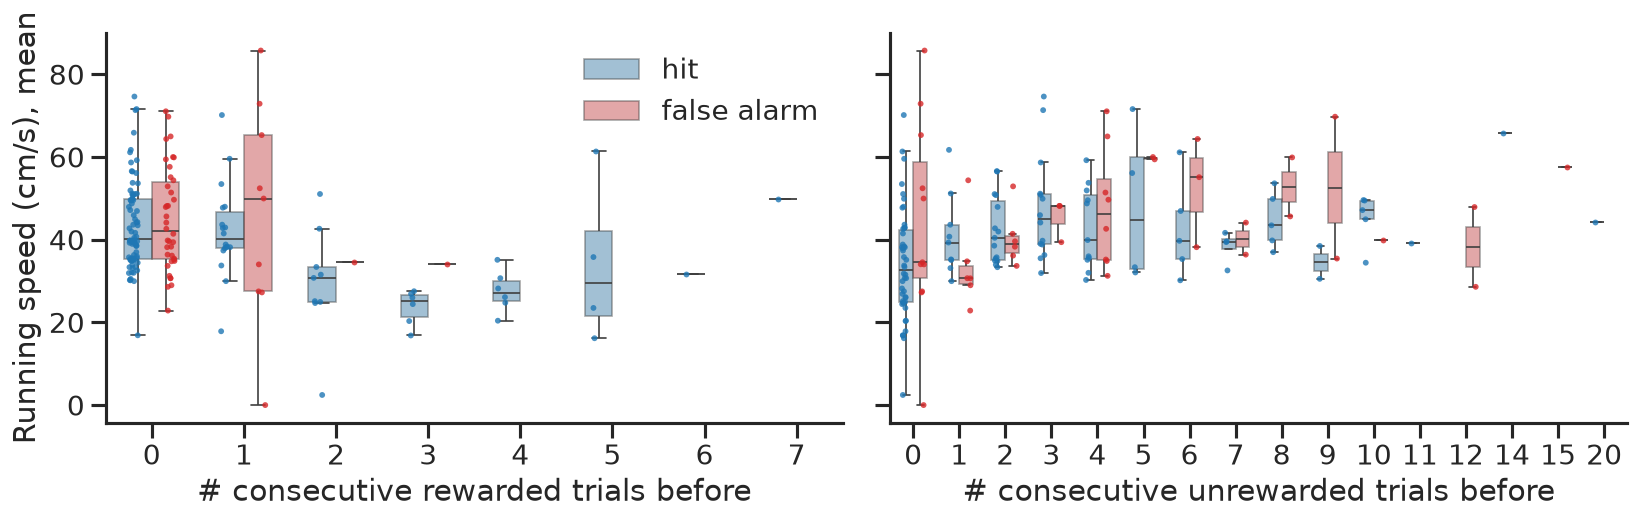

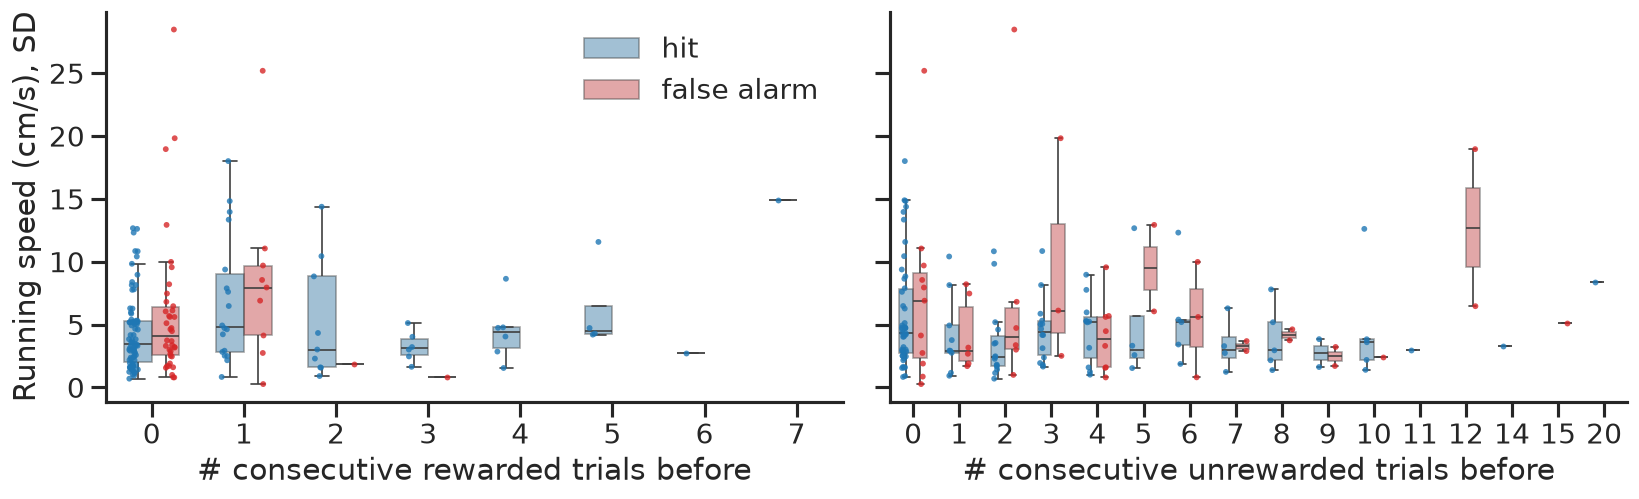

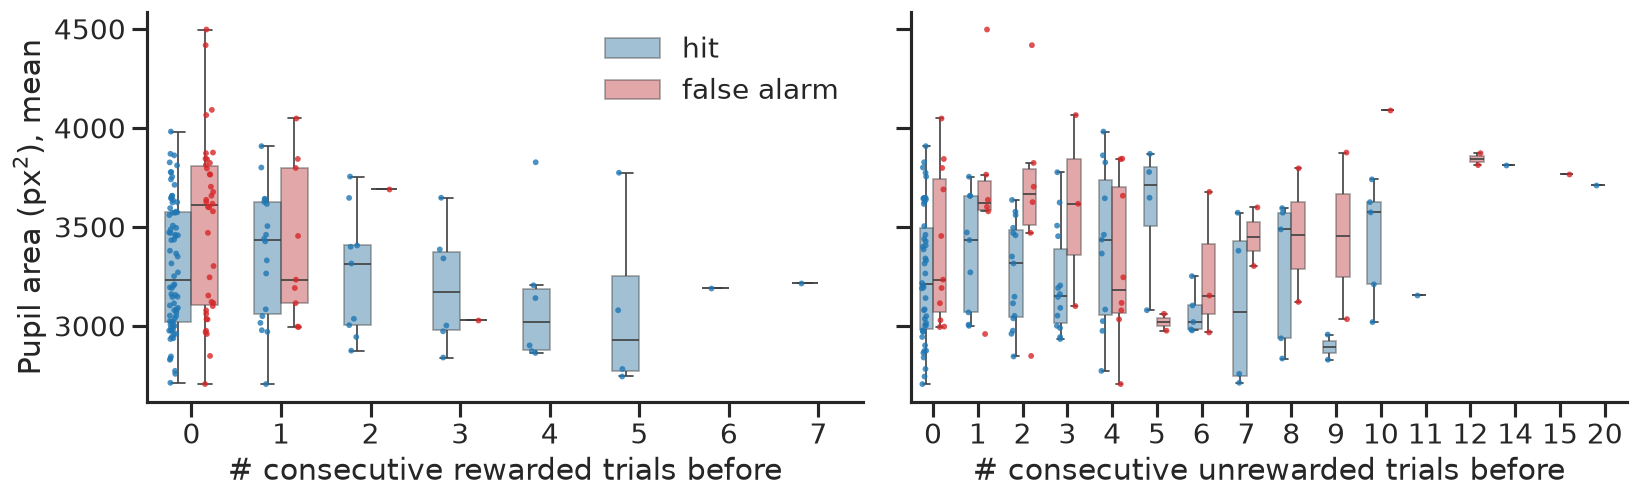

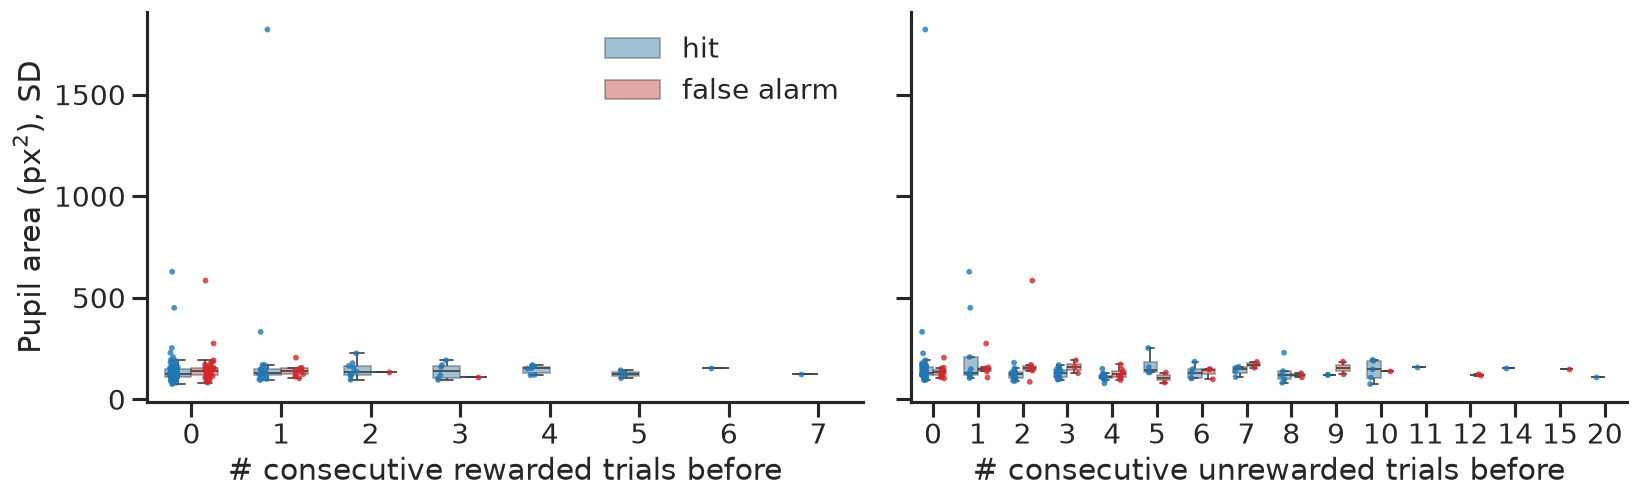

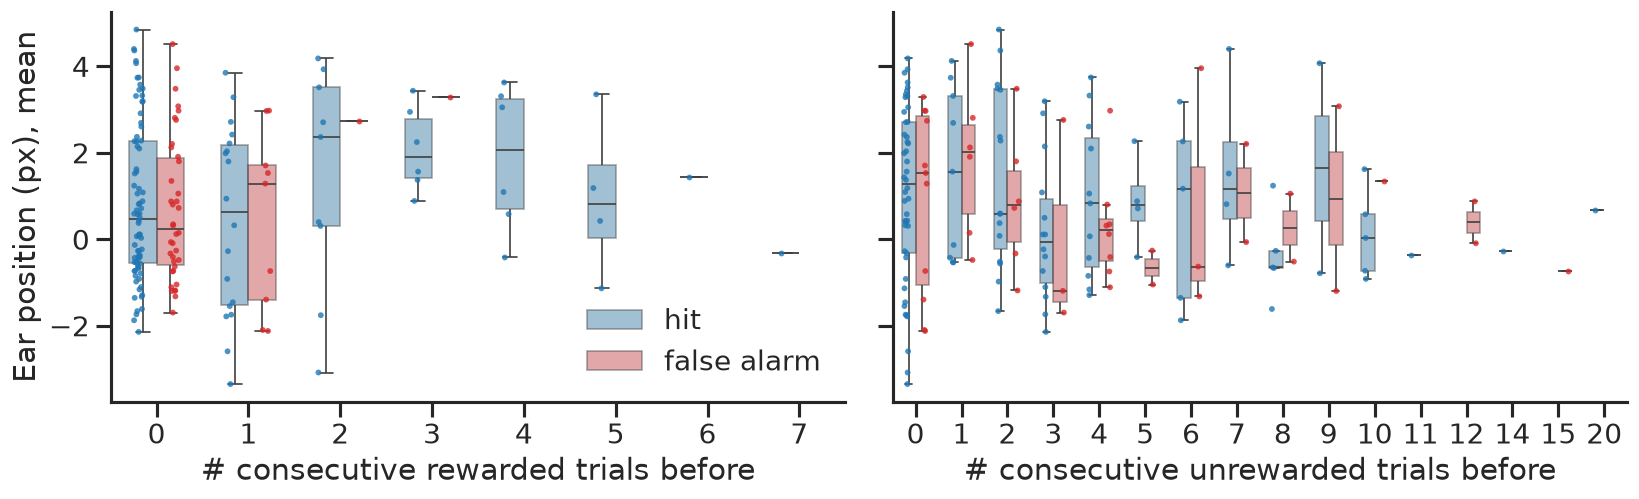

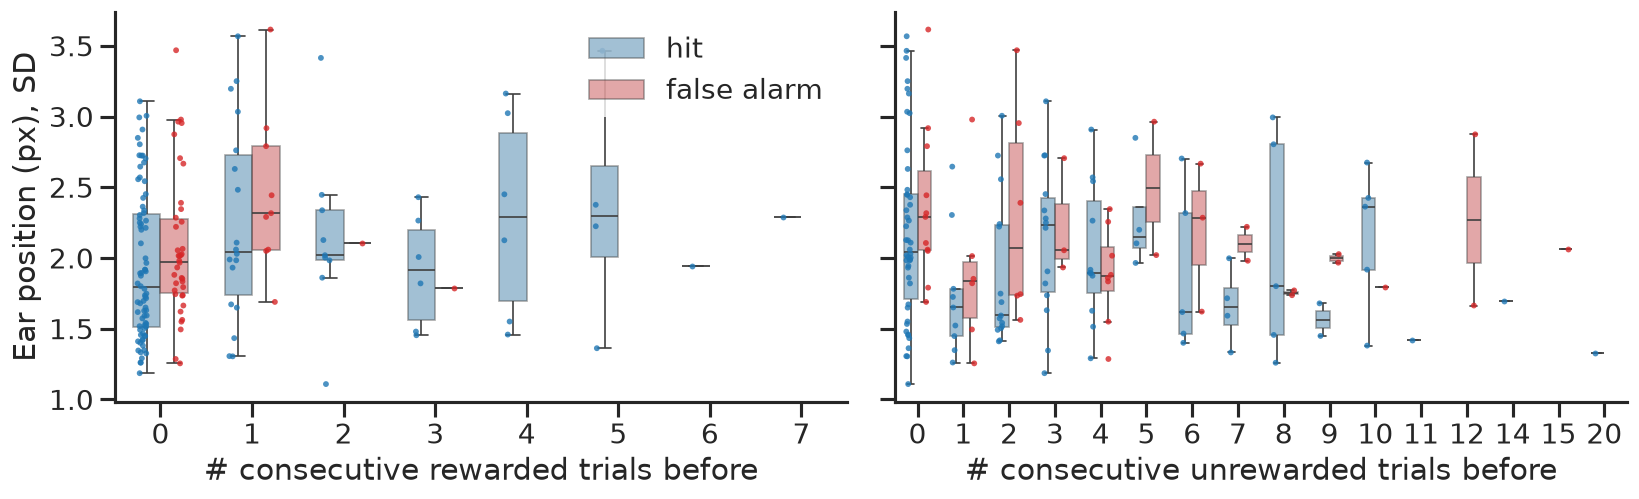

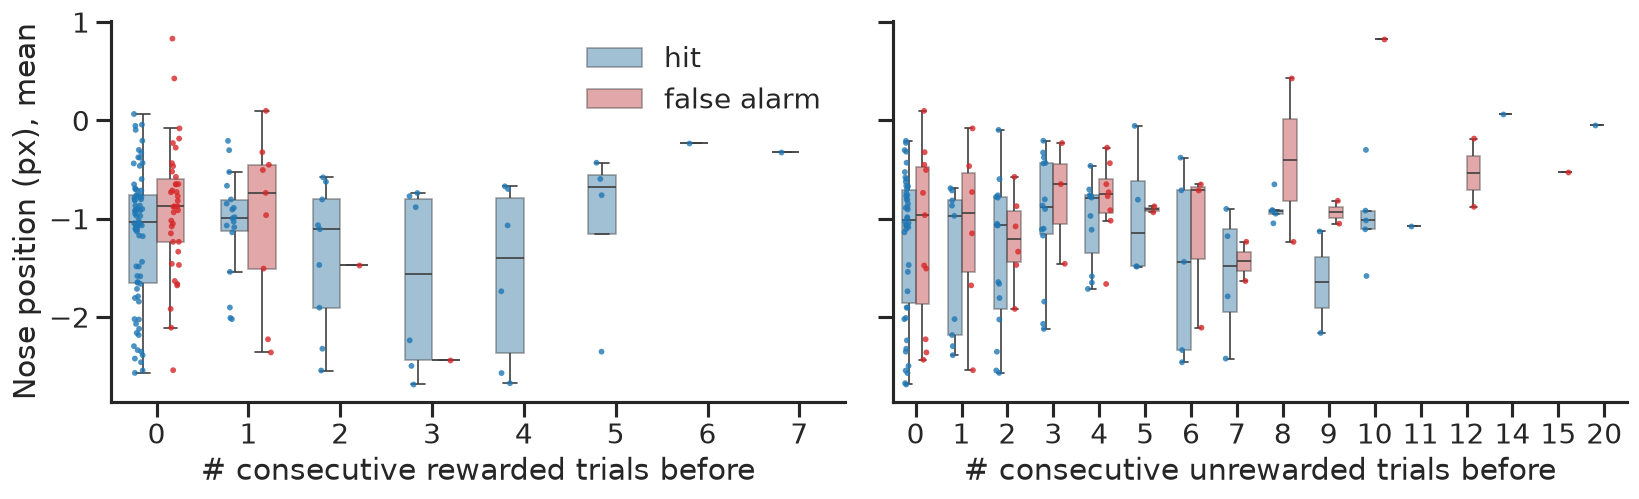

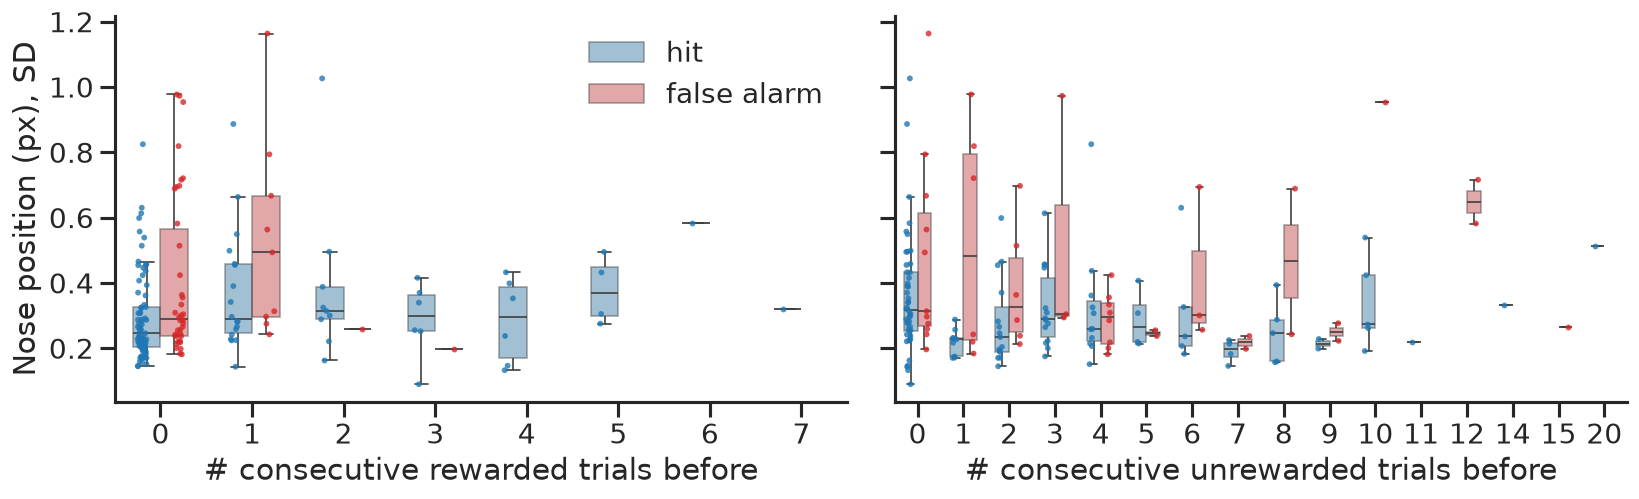

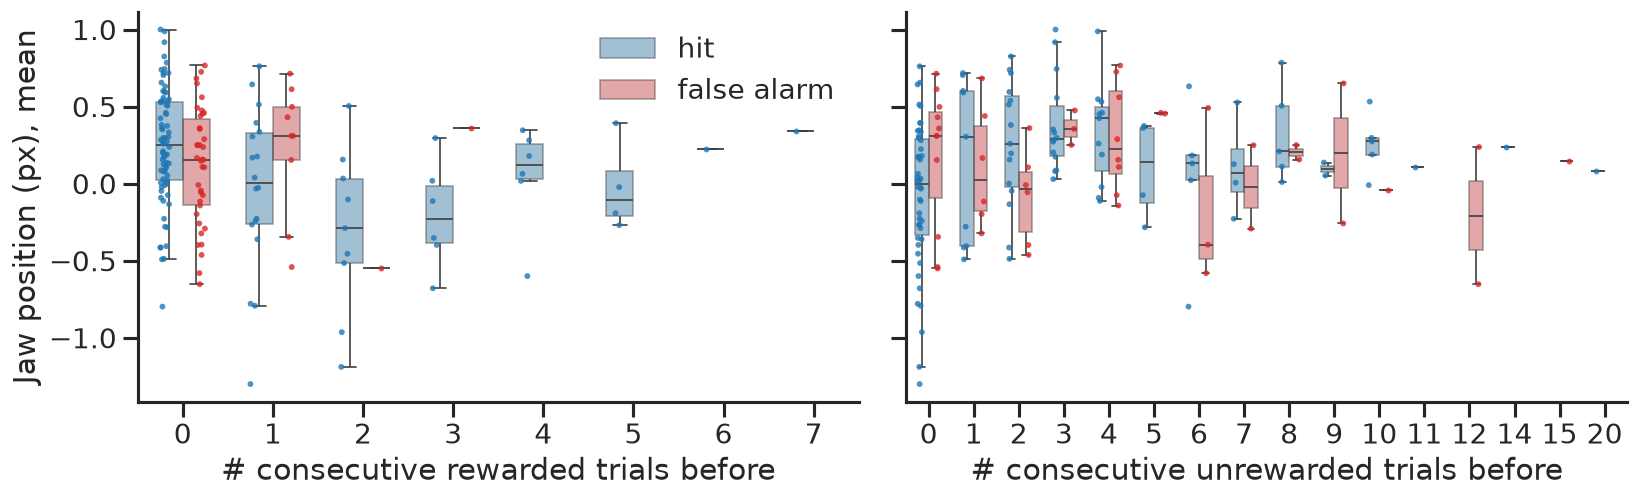

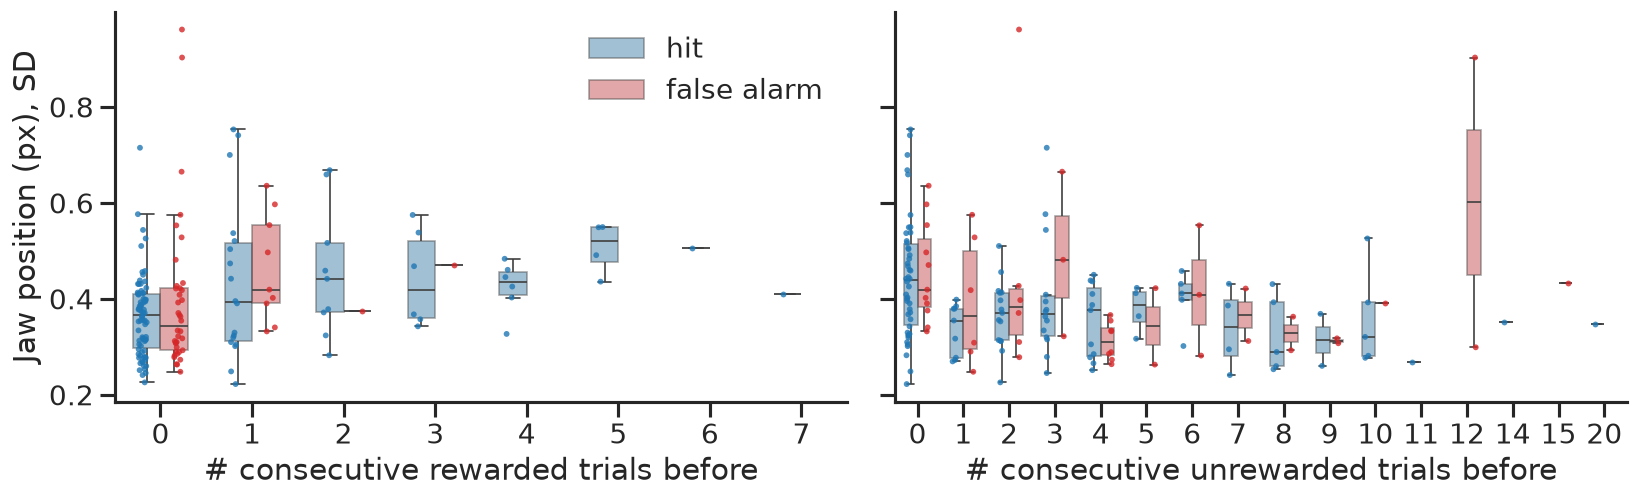

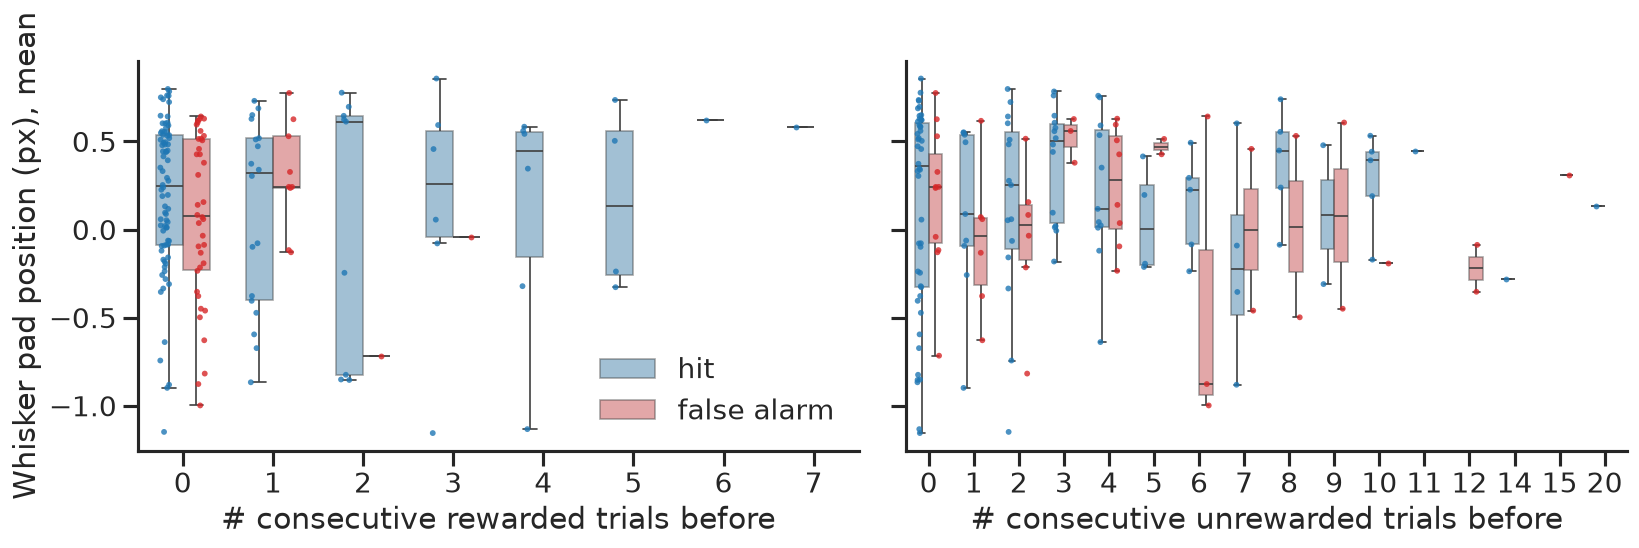

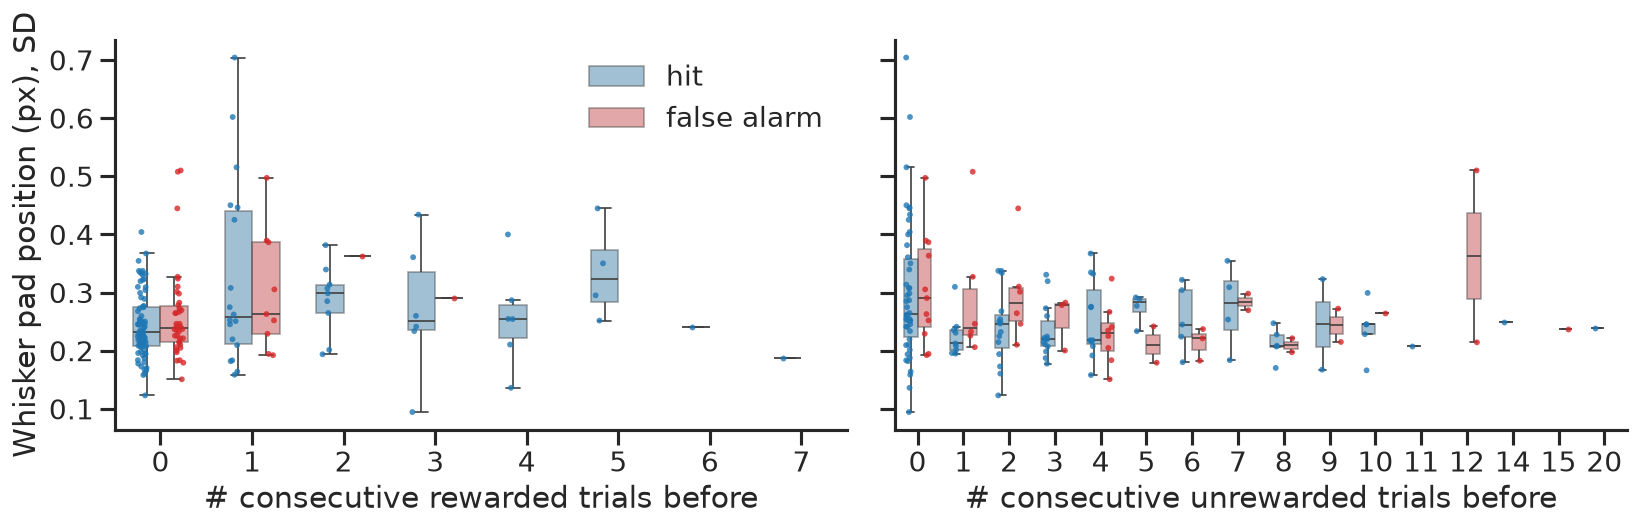

In [176]:
STREAK_COLUMNS = [('consecutive_rewarded', '# consecutive rewarded trials before'), ('consecutive_unrewarded', '# consecutive unrewarded trials before')]
OUTCOME_COLORS = {'hit': 'tab:blue', 'false alarm': 'tab:red'}
RT_OUTCOMES = ['hit', 'false alarm']
STATISTICS = [('_mean', 'mean'), ('_sd', 'SD')]

behavior_streak_data = trials[~trials.is_catch & trials.outcome.isin(RT_OUTCOMES)].copy()

for behavior_column, behavior_label in BEHAVIOR_VARIABLES:
    for statistic_suffix, statistic_label in STATISTICS:
        value_column = behavior_column + statistic_suffix
        panel_data = behavior_streak_data[behavior_streak_data[value_column].notna()]

        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

        for col_index, (streak_column, column_label) in enumerate(STREAK_COLUMNS):
            ax = axes[col_index]
            level_order = sorted(panel_data[streak_column].unique())

            sns.boxplot(data=panel_data, x=streak_column, y=value_column,
                        hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                        order=level_order, width=0.6, showfliers=False, linewidth=1,
                        boxprops={'alpha': 0.45},
                        legend=(col_index == 0), ax=ax)
            sns.stripplot(data=panel_data, x=streak_column, y=value_column,
                          hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                          order=level_order, dodge=True, size=3.5, alpha=0.8,
                          linewidth=0, legend=False, ax=ax)

            ax.set_xlabel(column_label)
            ax.set_ylabel('%s, %s' % (behavior_label, statistic_label)
                          if col_index == 0 else '')
            sns.despine(ax=ax)

        legend = axes[0].get_legend()
        if legend is not None:
            legend.set_title('')
            legend.prop.set_size(9)
            legend.get_frame().set_linewidth(0)

        fig.tight_layout()
        plt.show()

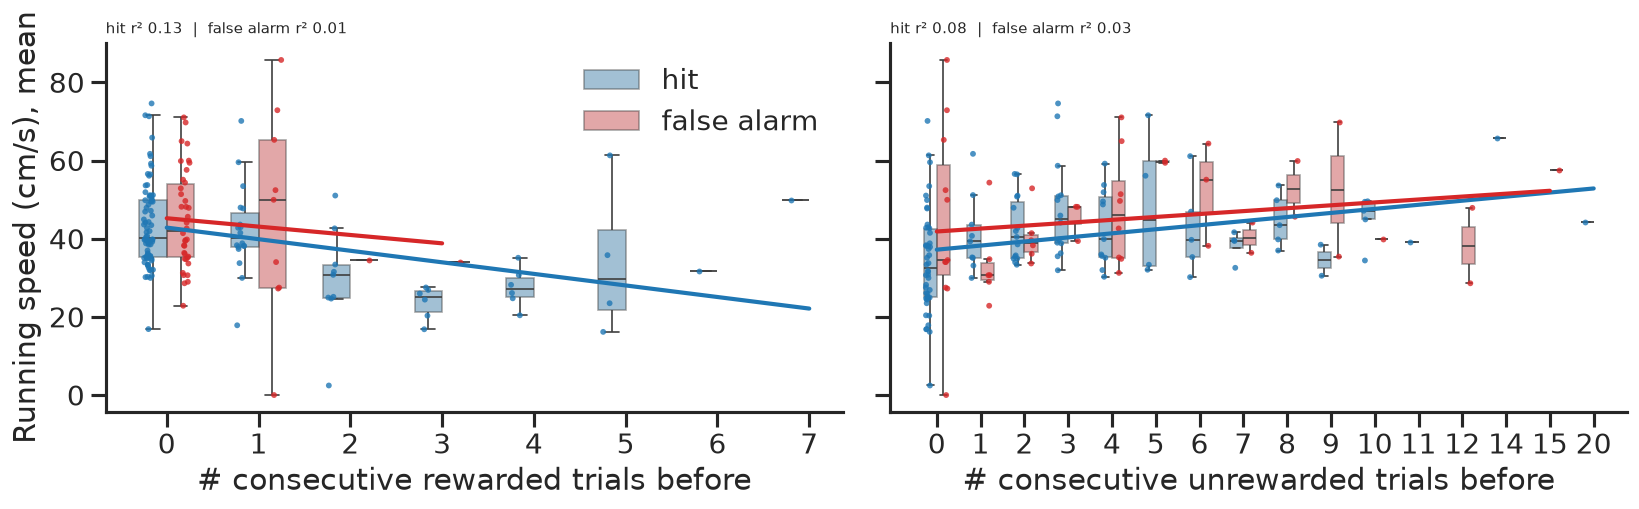

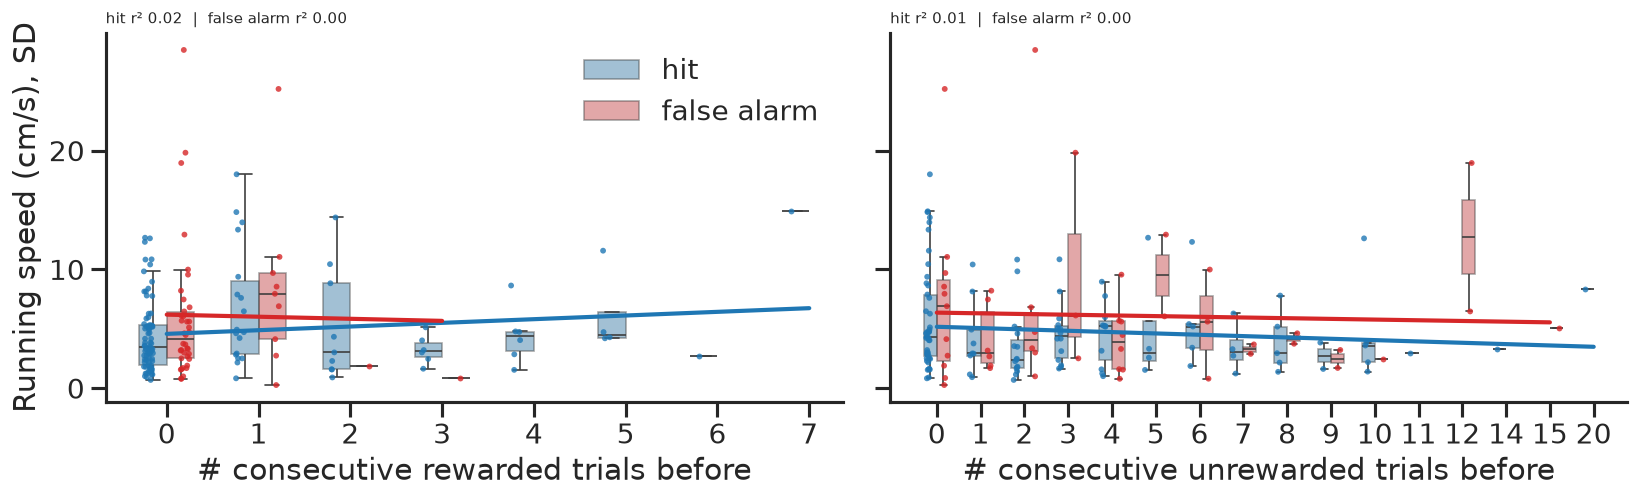

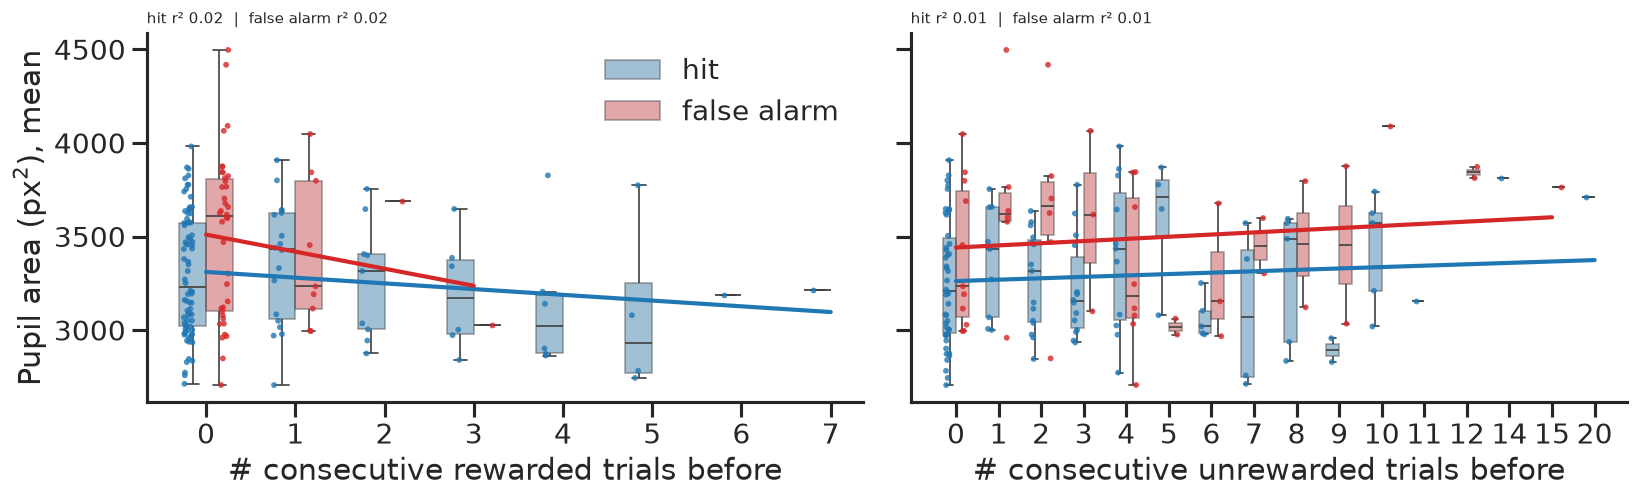

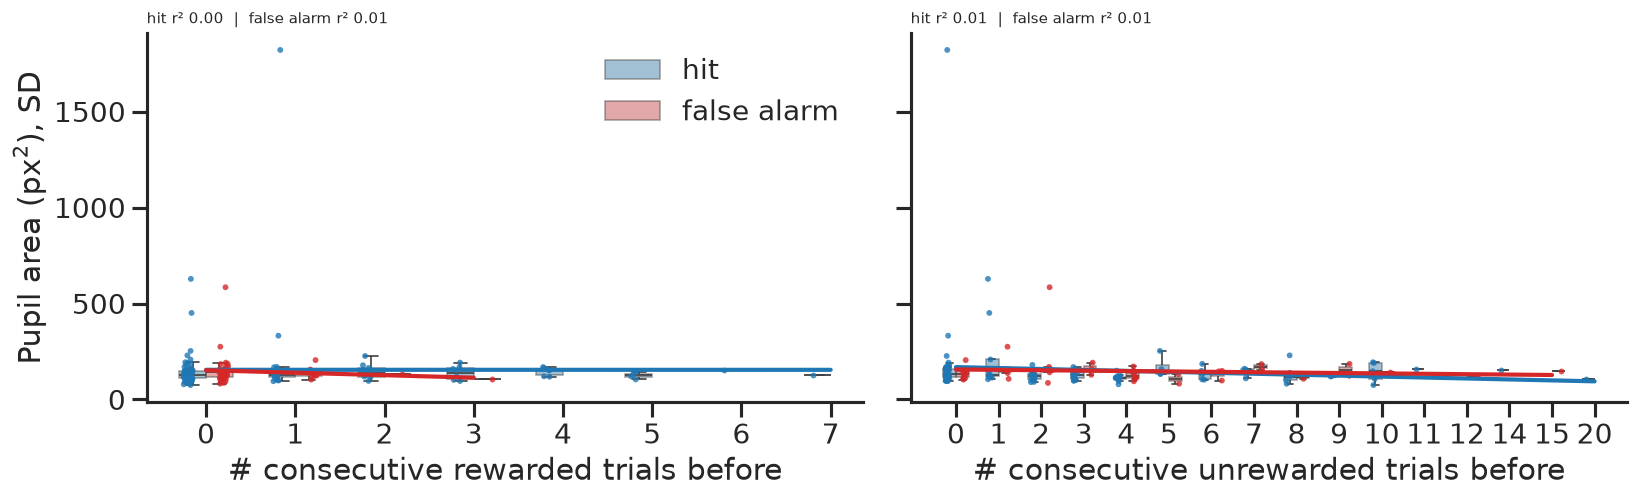

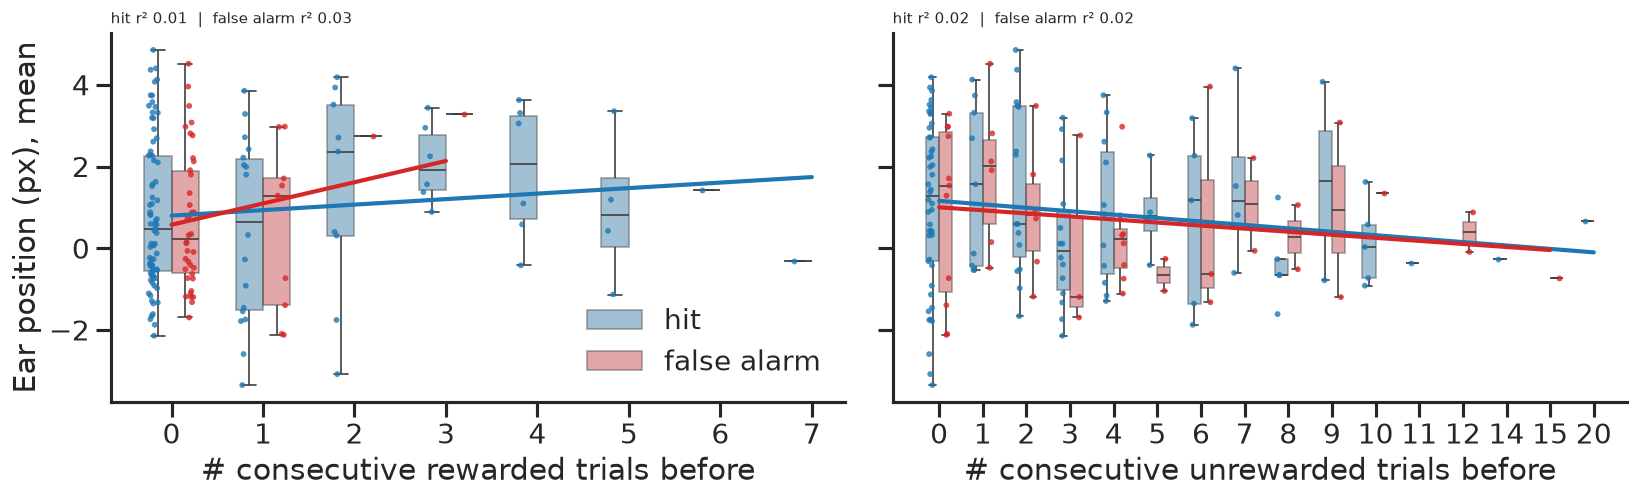

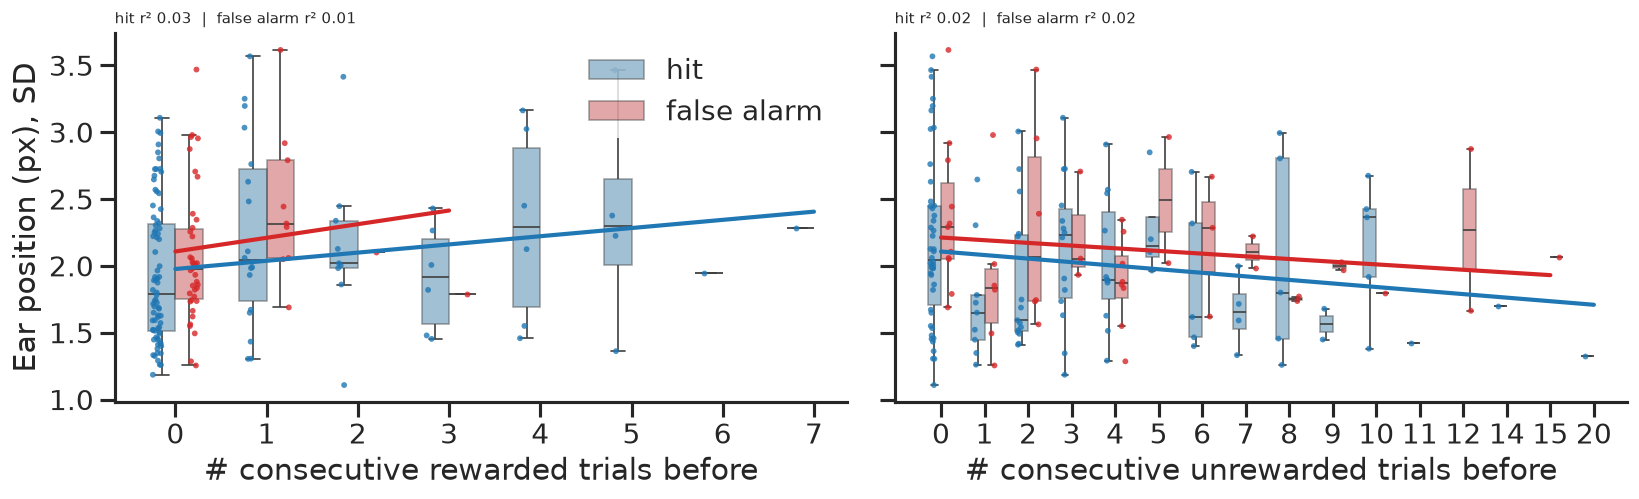

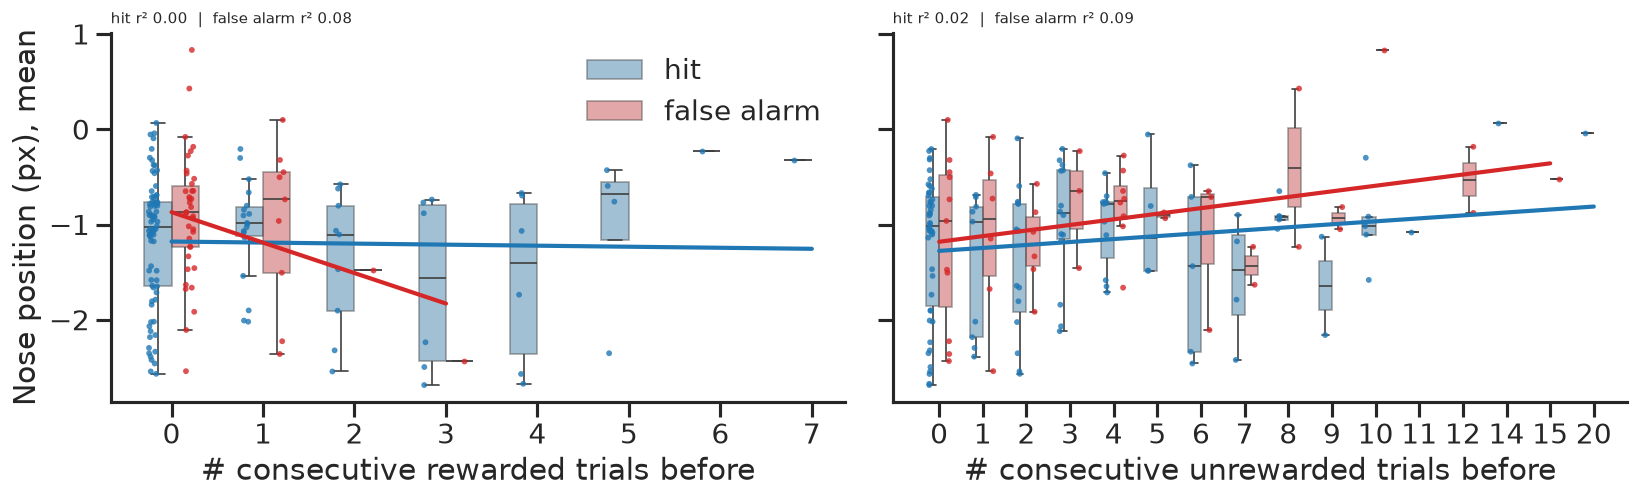

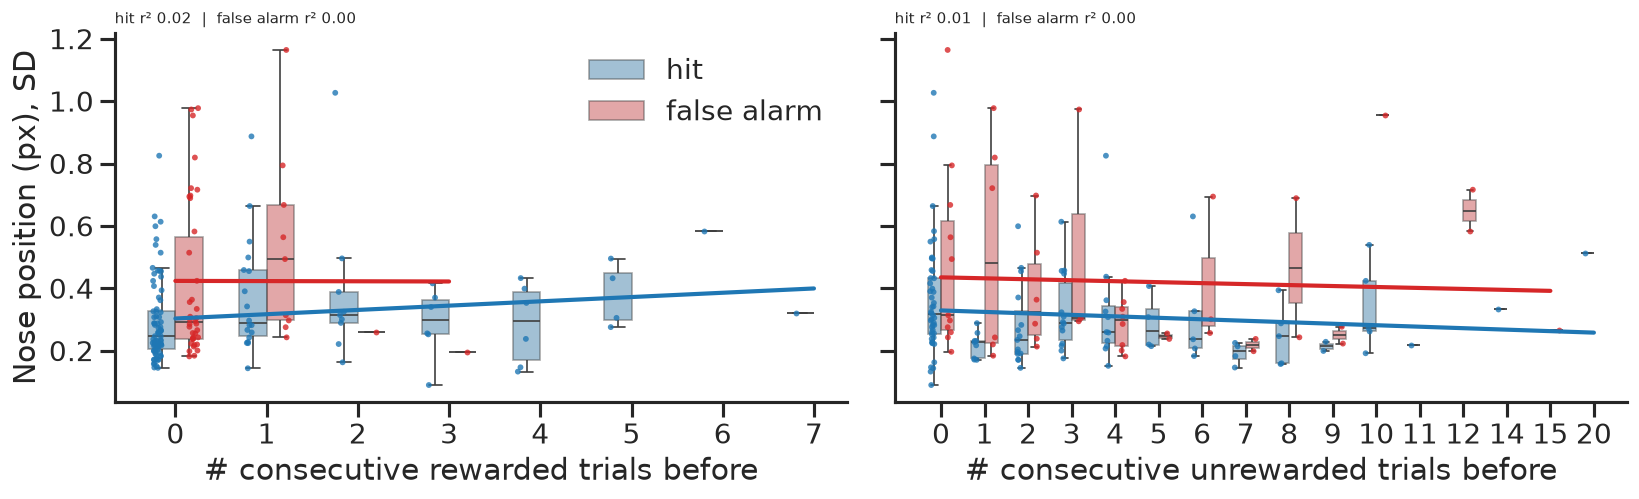

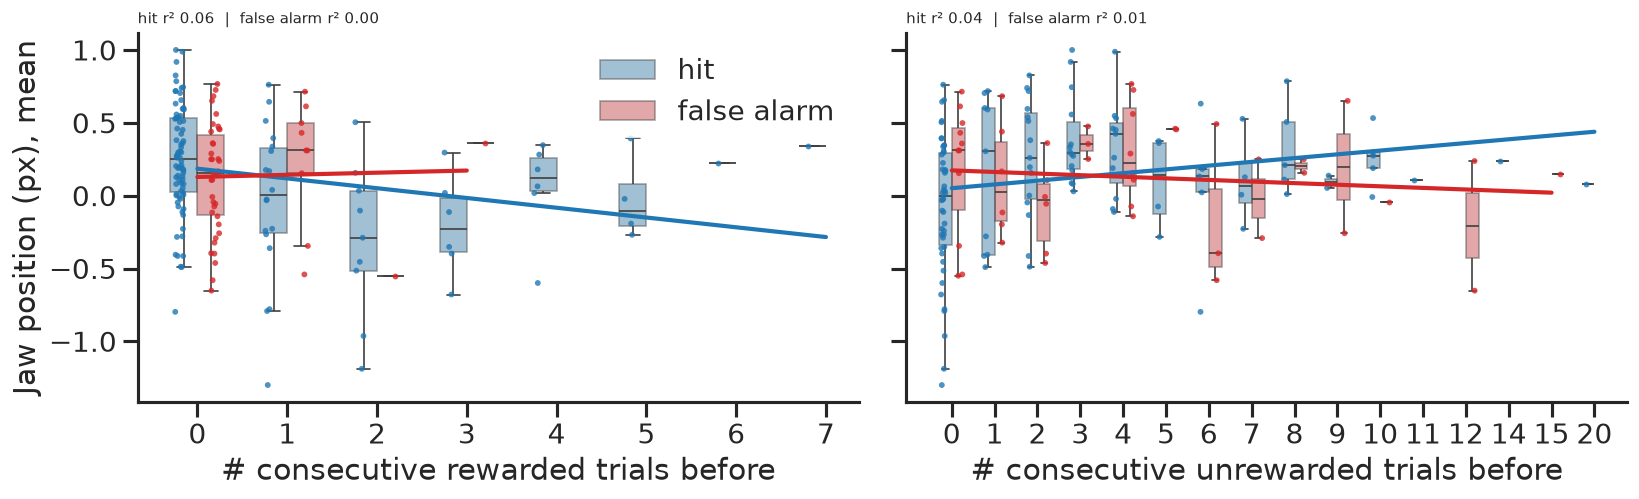

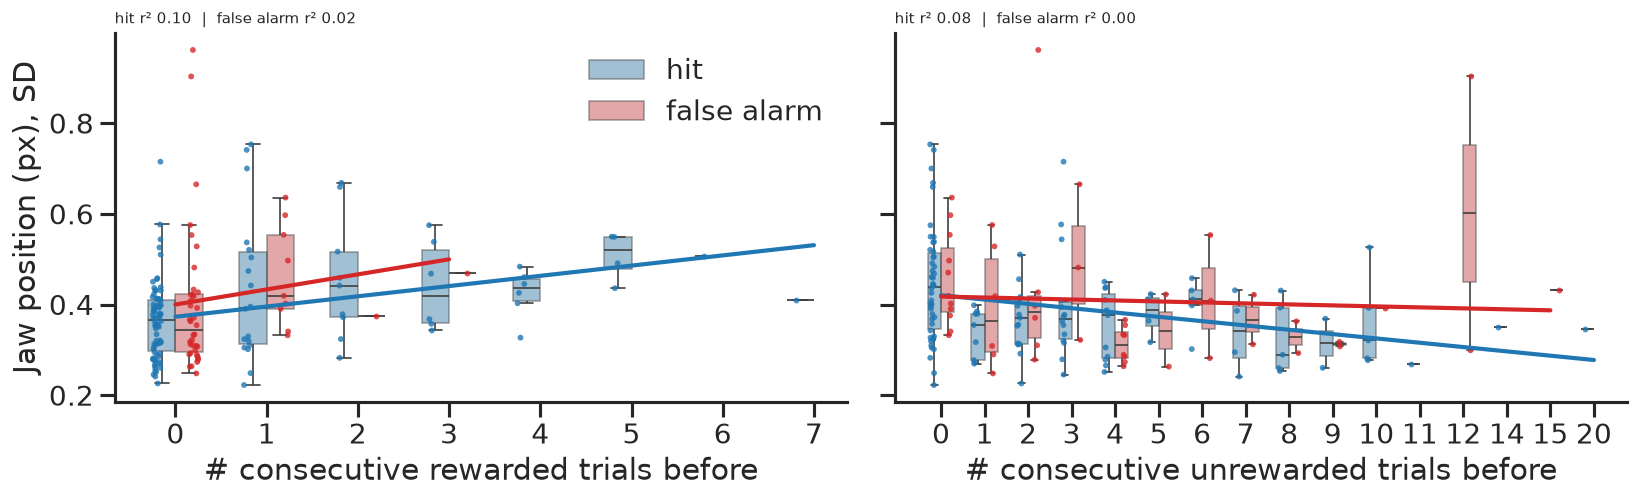

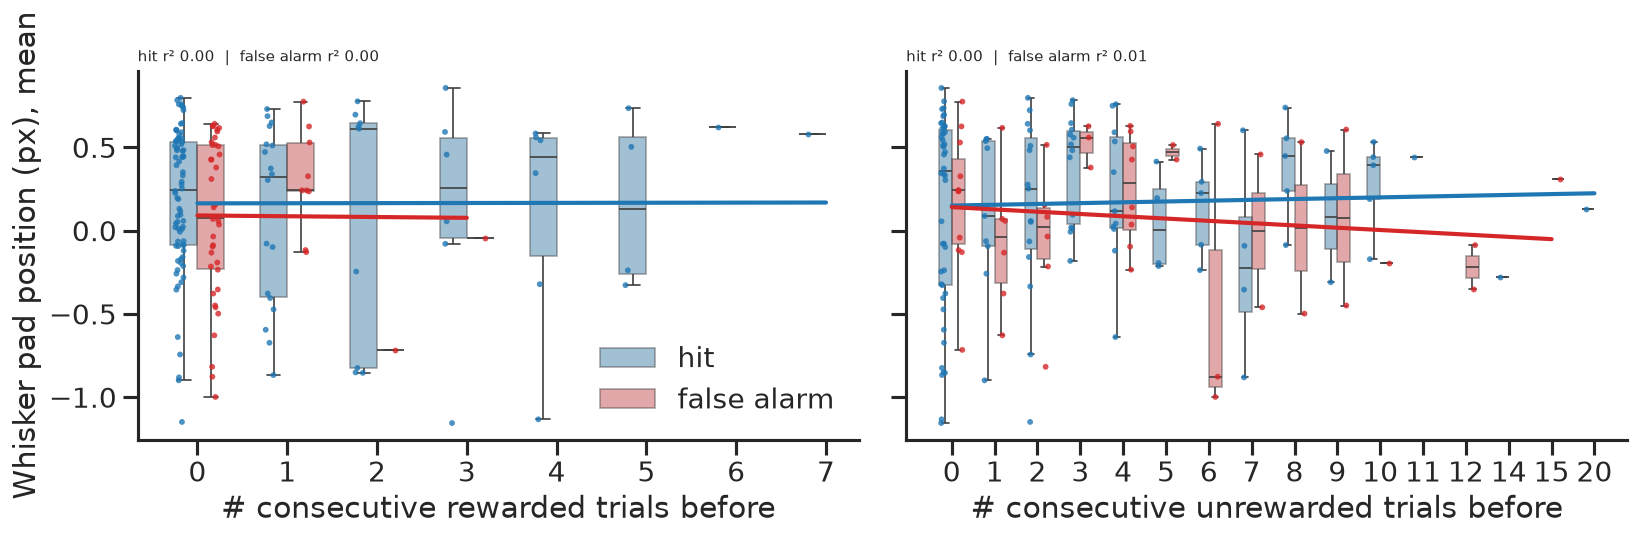

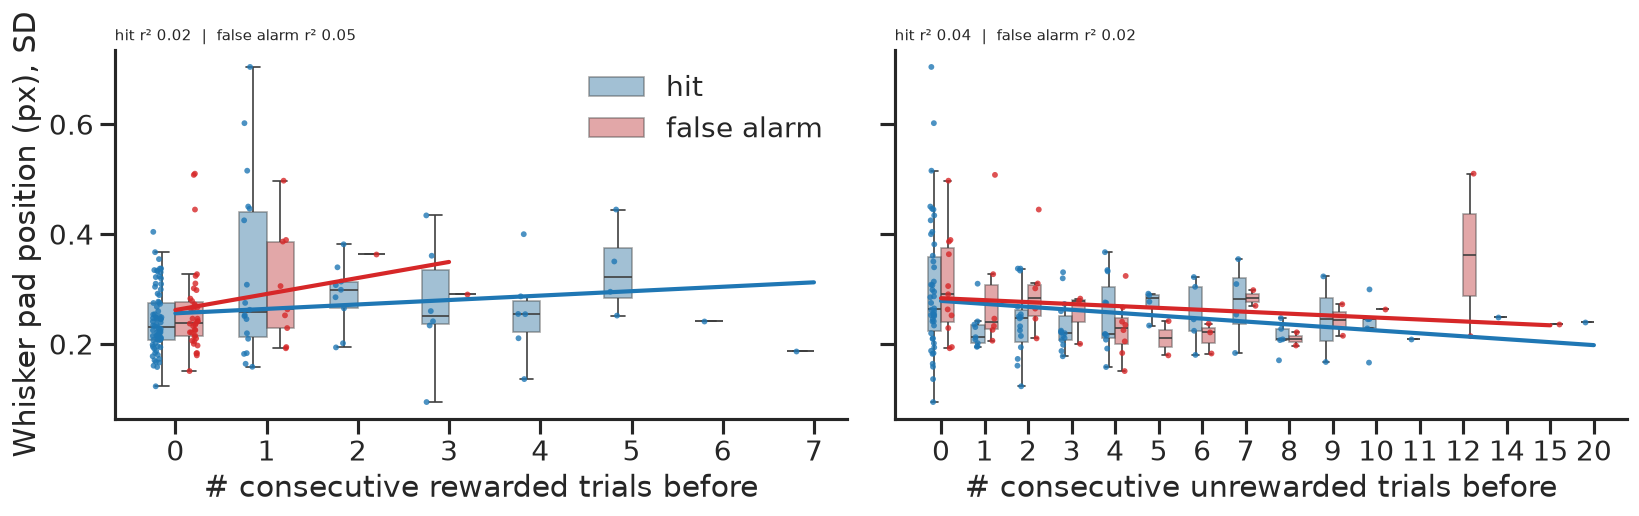

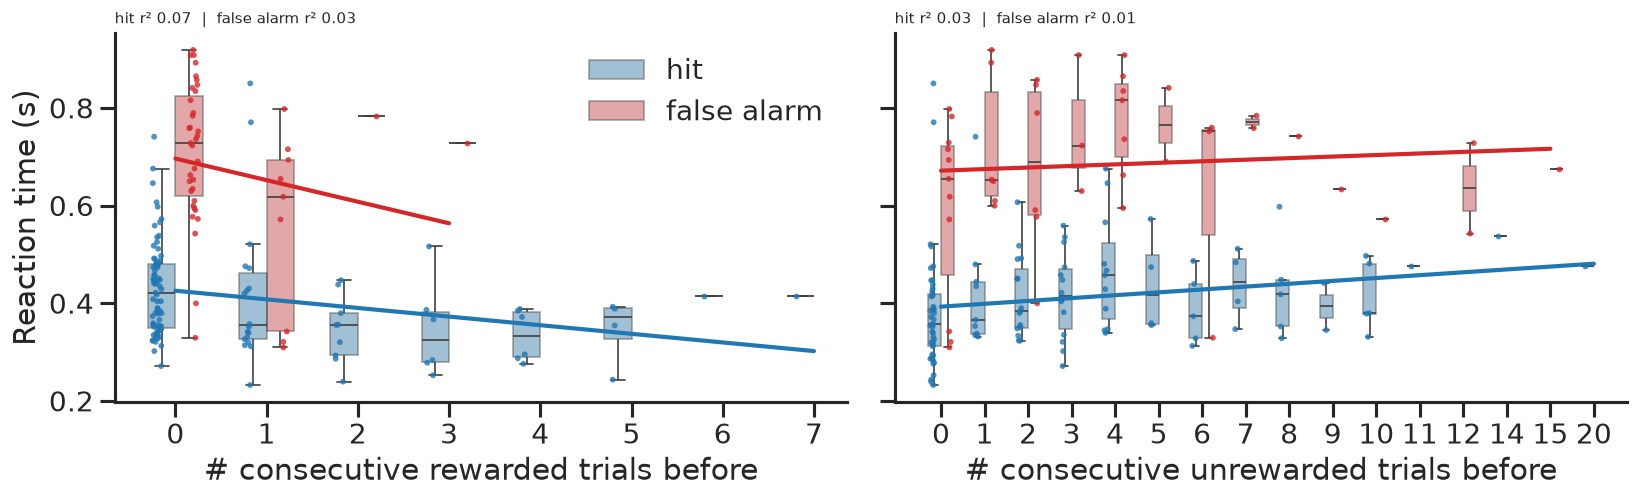

                       variable                                 streak     outcome   slope  slope_std  stderr_std    r2     p   n
     Running speed (cm/s), mean   # consecutive rewarded trials before         hit  -2.959     -0.367       0.085 0.134 0.000 123
          Jaw position (px), SD   # consecutive rewarded trials before         hit   0.023      0.319       0.086 0.101 0.000 123
       Nose position (px), mean # consecutive unrewarded trials before false alarm   0.059      0.300       0.139 0.090 0.036  49
          Jaw position (px), SD # consecutive unrewarded trials before         hit  -0.010     -0.291       0.087 0.084 0.001 123
     Running speed (cm/s), mean # consecutive unrewarded trials before         hit   1.044      0.279       0.087 0.078 0.002 123
       Nose position (px), mean   # consecutive rewarded trials before false alarm  -0.320     -0.275       0.140 0.076 0.056  49
              Reaction time (s)   # consecutive rewarded trials before         hit  -0.018

In [177]:
MIN_TRIALS_FOR_FIT = 20

behavior_streak_data = trials[~trials.is_catch & trials.outcome.isin(RT_OUTCOMES)].copy()

slope_rows = []

for behavior_column, behavior_label in BEHAVIOR_VARIABLES + [('reaction_time', None)]:
    statistic_list = STATISTICS if behavior_label is not None else [('', '')]
    for statistic_suffix, statistic_label in statistic_list:
        value_column = behavior_column + statistic_suffix
        if value_column not in behavior_streak_data:
            continue
        panel_label = ('Reaction time (s)' if behavior_label is None else '%s, %s' % (behavior_label, statistic_label))
        panel_data = behavior_streak_data[behavior_streak_data[value_column].notna()]

        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

        for col_index, (streak_column, column_label) in enumerate(STREAK_COLUMNS):
            ax = axes[col_index]
            level_order = sorted(panel_data[streak_column].unique())

            sns.boxplot(data=panel_data, x=streak_column, y=value_column,
                        hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                        order=level_order, width=0.6, showfliers=False, linewidth=1,
                        boxprops={'alpha': 0.45},
                        legend=(col_index == 0), ax=ax)
            sns.stripplot(data=panel_data, x=streak_column, y=value_column,
                          hue='outcome', hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                          order=level_order, dodge=True, size=3.5, alpha=0.8,
                          linewidth=0, legend=False, ax=ax)

            position_by_level = {level: position for position, level in enumerate(level_order)}
            title_parts = []
            for outcome_label in RT_OUTCOMES:
                outcome_data = panel_data[panel_data.outcome == outcome_label]
                x = outcome_data[streak_column].map(
                    position_by_level).values.astype(float)
                y = outcome_data[value_column].values.astype(float)

                if len(x) < MIN_TRIALS_FOR_FIT or len(np.unique(x)) < 2:
                    title_parts.append('%s: n=%d, not fitted' % (outcome_label, len(x)))
                    continue

                result = linregress(x, y)
                x_line = np.array([x.min(), x.max()])
                ax.plot(x_line, result.intercept + result.slope * x_line, color=OUTCOME_COLORS[outcome_label], lw=2.5, zorder=5)
                title_parts.append('%s r\u00b2 %.2f' % (outcome_label, result.rvalue ** 2))

                # Normalize slopes
                slope_rows.append({
                    'variable': panel_label,
                    'streak': column_label,
                    'outcome': outcome_label,
                    'slope': result.slope,
                    'slope_std': result.slope * x.std() / y.std() if y.std() > 0 else np.nan,
                    'stderr_std': result.stderr * x.std() / y.std() if y.std() > 0 else np.nan,
                    'r2': result.rvalue ** 2,
                    'p': result.pvalue,
                    'n': len(x)})

            ax.set_xlabel(column_label)
            ax.set_ylabel(panel_label if col_index == 0 else '')
            ax.set_title('  |  '.join(title_parts), fontsize=9)
            sns.despine(ax=ax)

        legend = axes[0].get_legend()
        if legend is not None:
            legend.set_title('')
            legend.prop.set_size(9)
            legend.get_frame().set_linewidth(0)

        fig.tight_layout()
        plt.show()

slope_table = pd.DataFrame(slope_rows)
print(slope_table.sort_values('slope_std', key=np.abs, ascending=False).to_string(index=False, float_format='%.3f'))

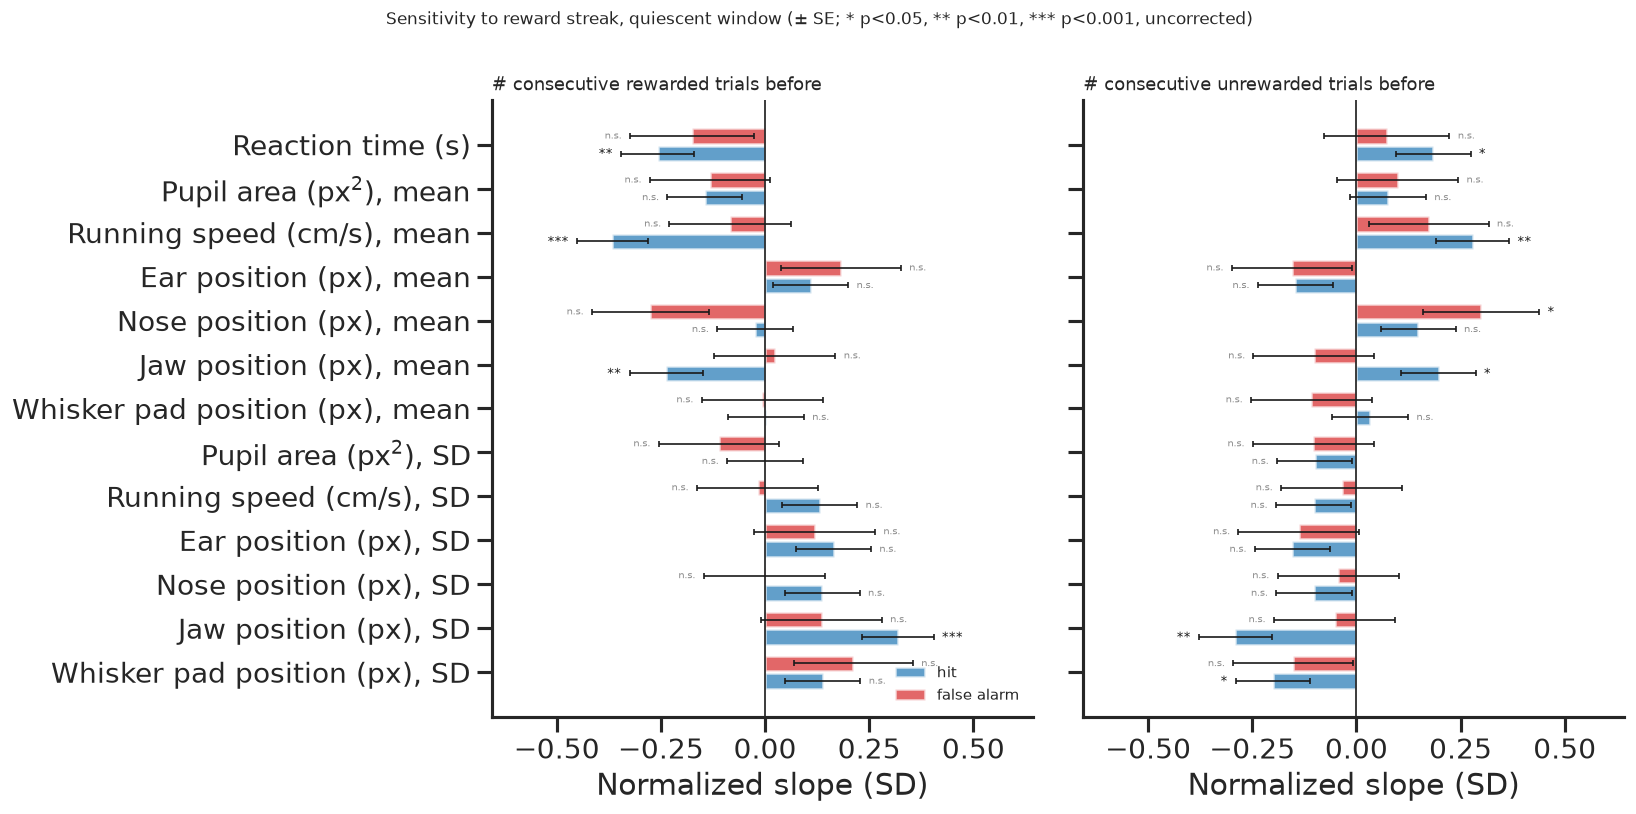

In [178]:
def significance_marker(p_value):
    """Conventional stars. 52 uncorrected tests here, so a single star is weak."""
    if not np.isfinite(p_value):
        return ''
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'n.s.'


# Order to show
VARIABLE_SEQUENCE = ['pupil_area', 'running_speed', 'ear', 'nose', 'jaw', 'whiskers']
label_by_column = dict(BEHAVIOR_VARIABLES)

variable_order = ['Reaction time (s)']
for statistic_label in ['mean', 'SD']:
    for behavior_column in VARIABLE_SEQUENCE:
        if behavior_column in label_by_column:
            variable_order.append('%s, %s' % (label_by_column[behavior_column], statistic_label))
variable_order = [v for v in variable_order if v in set(slope_table.variable)]

y_position = {variable: position for position, variable in enumerate(reversed(variable_order))}

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)

for panel_index, (_, column_label) in enumerate(STREAK_COLUMNS):
    ax = axes[panel_index]
    panel_table = slope_table[slope_table.streak == column_label]

    for outcome_label, offset in zip(RT_OUTCOMES, [-0.2, 0.2]):
        outcome_table = panel_table[panel_table.variable.isin(y_position) & (panel_table.outcome == outcome_label)]
        positions = outcome_table.variable.map(y_position).values + offset
        ax.barh(positions, outcome_table.slope_std, height=0.35, color=OUTCOME_COLORS[outcome_label], alpha=0.7,
            label=outcome_label if panel_index == 0 else None)
        ax.errorbar(outcome_table.slope_std, positions, xerr=outcome_table.stderr_std, fmt='none', ecolor='k', lw=1, capsize=2)

        for bar_position, slope_value, stderr_value, p_value in zip(positions, outcome_table.slope_std, outcome_table.stderr_std, outcome_table.p):
            marker = significance_marker(p_value)
            if not marker:
                continue
            direction = 1 if slope_value >= 0 else -1
            label_x = slope_value + direction * (abs(stderr_value) + 0.02)
            ax.annotate(marker, (label_x, bar_position),
                        ha='left' if direction > 0 else 'right', va='center',
                        fontsize=8 if marker != 'n.s.' else 6,
                        color='k' if marker != 'n.s.' else '0.55')

    ax.axvline(0, color='k', lw=1)
    ax.set_yticks(range(len(variable_order)))
    ax.set_yticklabels(list(reversed(variable_order)))
    ax.set_xlabel('Normalized slope (SD)')
    ax.set_title(column_label, fontsize=11)
    sns.despine(ax=ax)

for ax in axes:
    x_low, x_high = ax.get_xlim()
    ax.set_xlim(x_low - 0.08, x_high + 0.08)

axes[0].legend(fontsize=9, frameon=False, loc='lower right')
fig.suptitle('Sensitivity to reward streak, %s window (\u00b1 SE; ' '* p<0.05, ** p<0.01, *** p<0.001, uncorrected)' % TRIAL_WINDOW, fontsize=10)
fig.tight_layout()
plt.show()

2 of 52 fits at p < 0.001


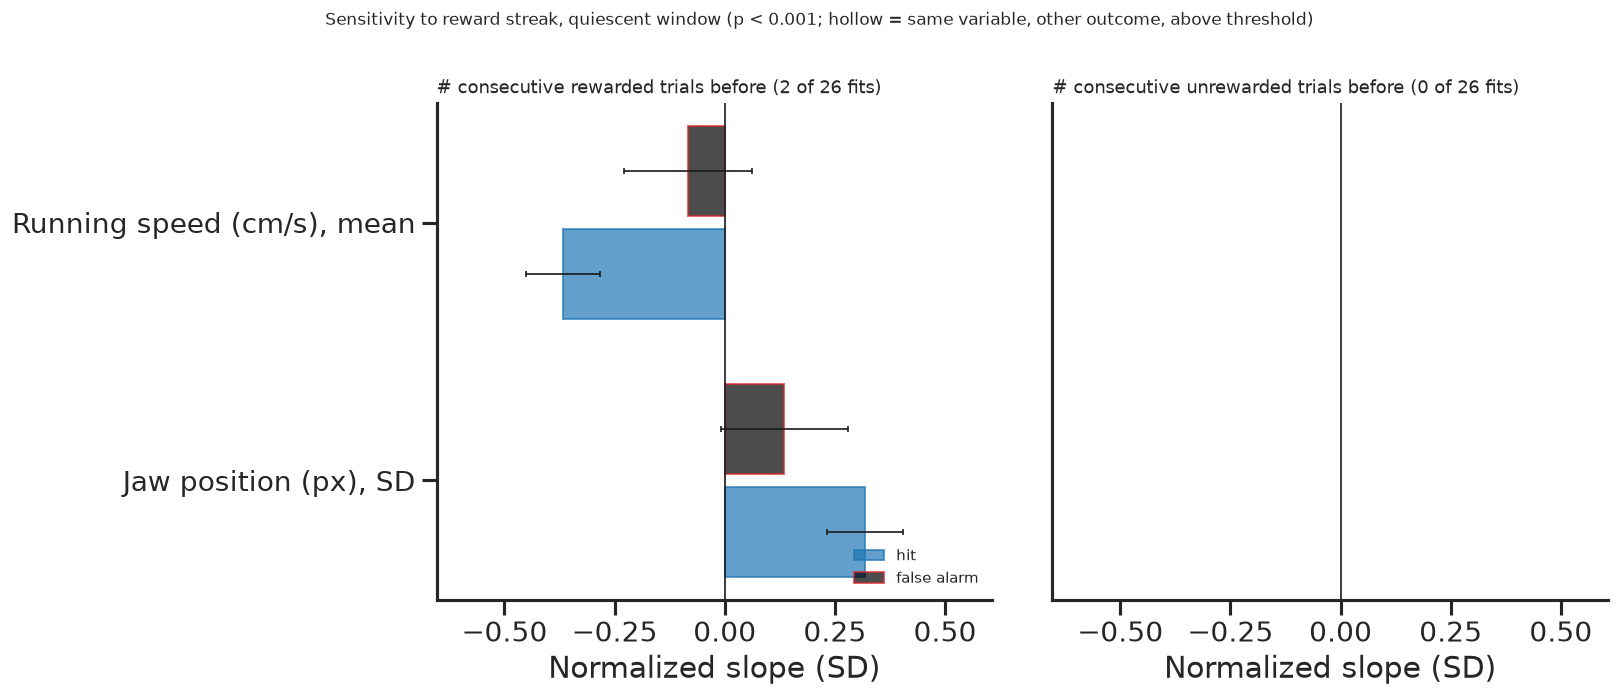

In [179]:
P_THRESHOLD = 0.001

# rows where at least one outcome passes; the other is drawn hollow so the
# figure never implies only one estimate was fitted
significant_keys = set(
    slope_table.loc[slope_table.p < P_THRESHOLD, ['variable', 'streak']]
    .itertuples(index=False, name=None))
significant_table = slope_table[
    slope_table.apply(lambda r: (r.variable, r.streak) in significant_keys, axis=1)]

print('%d of %d fits at p < %.3f'
      % (int((slope_table.p < P_THRESHOLD).sum()), len(slope_table), P_THRESHOLD))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

for panel_index, (_, column_label) in enumerate(STREAK_COLUMNS):
    ax = axes[panel_index]
    panel_table = significant_table[significant_table.streak == column_label]

    # keep the fixed variable order, restricted to what survived in this panel
    panel_variables = [v for v in variable_order if v in set(panel_table.variable)]
    panel_position = {variable: position
                      for position, variable in enumerate(reversed(panel_variables))}

    for outcome_label, offset in zip(RT_OUTCOMES, [-0.2, 0.2]):
        outcome_table = panel_table[panel_table.outcome == outcome_label]
        if not len(outcome_table):
            continue
        positions = outcome_table.variable.map(panel_position).values + offset
        is_significant = (outcome_table.p < P_THRESHOLD).values
        ax.barh(positions, outcome_table.slope_std, height=0.35,
                color=[OUTCOME_COLORS[outcome_label] if s else 'none'
                       for s in is_significant],
                edgecolor=OUTCOME_COLORS[outcome_label], linewidth=1.2,
                alpha=0.7, label=outcome_label if panel_index == 0 else None)
        ax.errorbar(outcome_table.slope_std, positions,
                    xerr=outcome_table.stderr_std, fmt='none',
                    ecolor='k', lw=1, capsize=2)

    ax.axvline(0, color='k', lw=1)
    ax.set_yticks(range(len(panel_variables)))
    ax.set_yticklabels(list(reversed(panel_variables)))
    ax.set_xlabel('Normalized slope (SD)')
    ax.set_title('%s (%d of %d fits)'
                 % (column_label,
                    int((slope_table[slope_table.streak == column_label].p
                         < P_THRESHOLD).sum()),
                    len(slope_table[slope_table.streak == column_label])),
                 fontsize=11)
    sns.despine(ax=ax)

for ax in axes:
    x_low, x_high = ax.get_xlim()
    ax.set_xlim(x_low - 0.08, x_high + 0.08)

axes[0].legend(fontsize=9, frameon=False, loc='lower right')
fig.suptitle('Sensitivity to reward streak, %s window (p < %.3f; '
             'hollow = same variable, other outcome, above threshold)'
             % (TRIAL_WINDOW, P_THRESHOLD), fontsize=10)
fig.tight_layout()
plt.show()